In [2]:
import numpy as np

import matplotlib.pyplot as plt

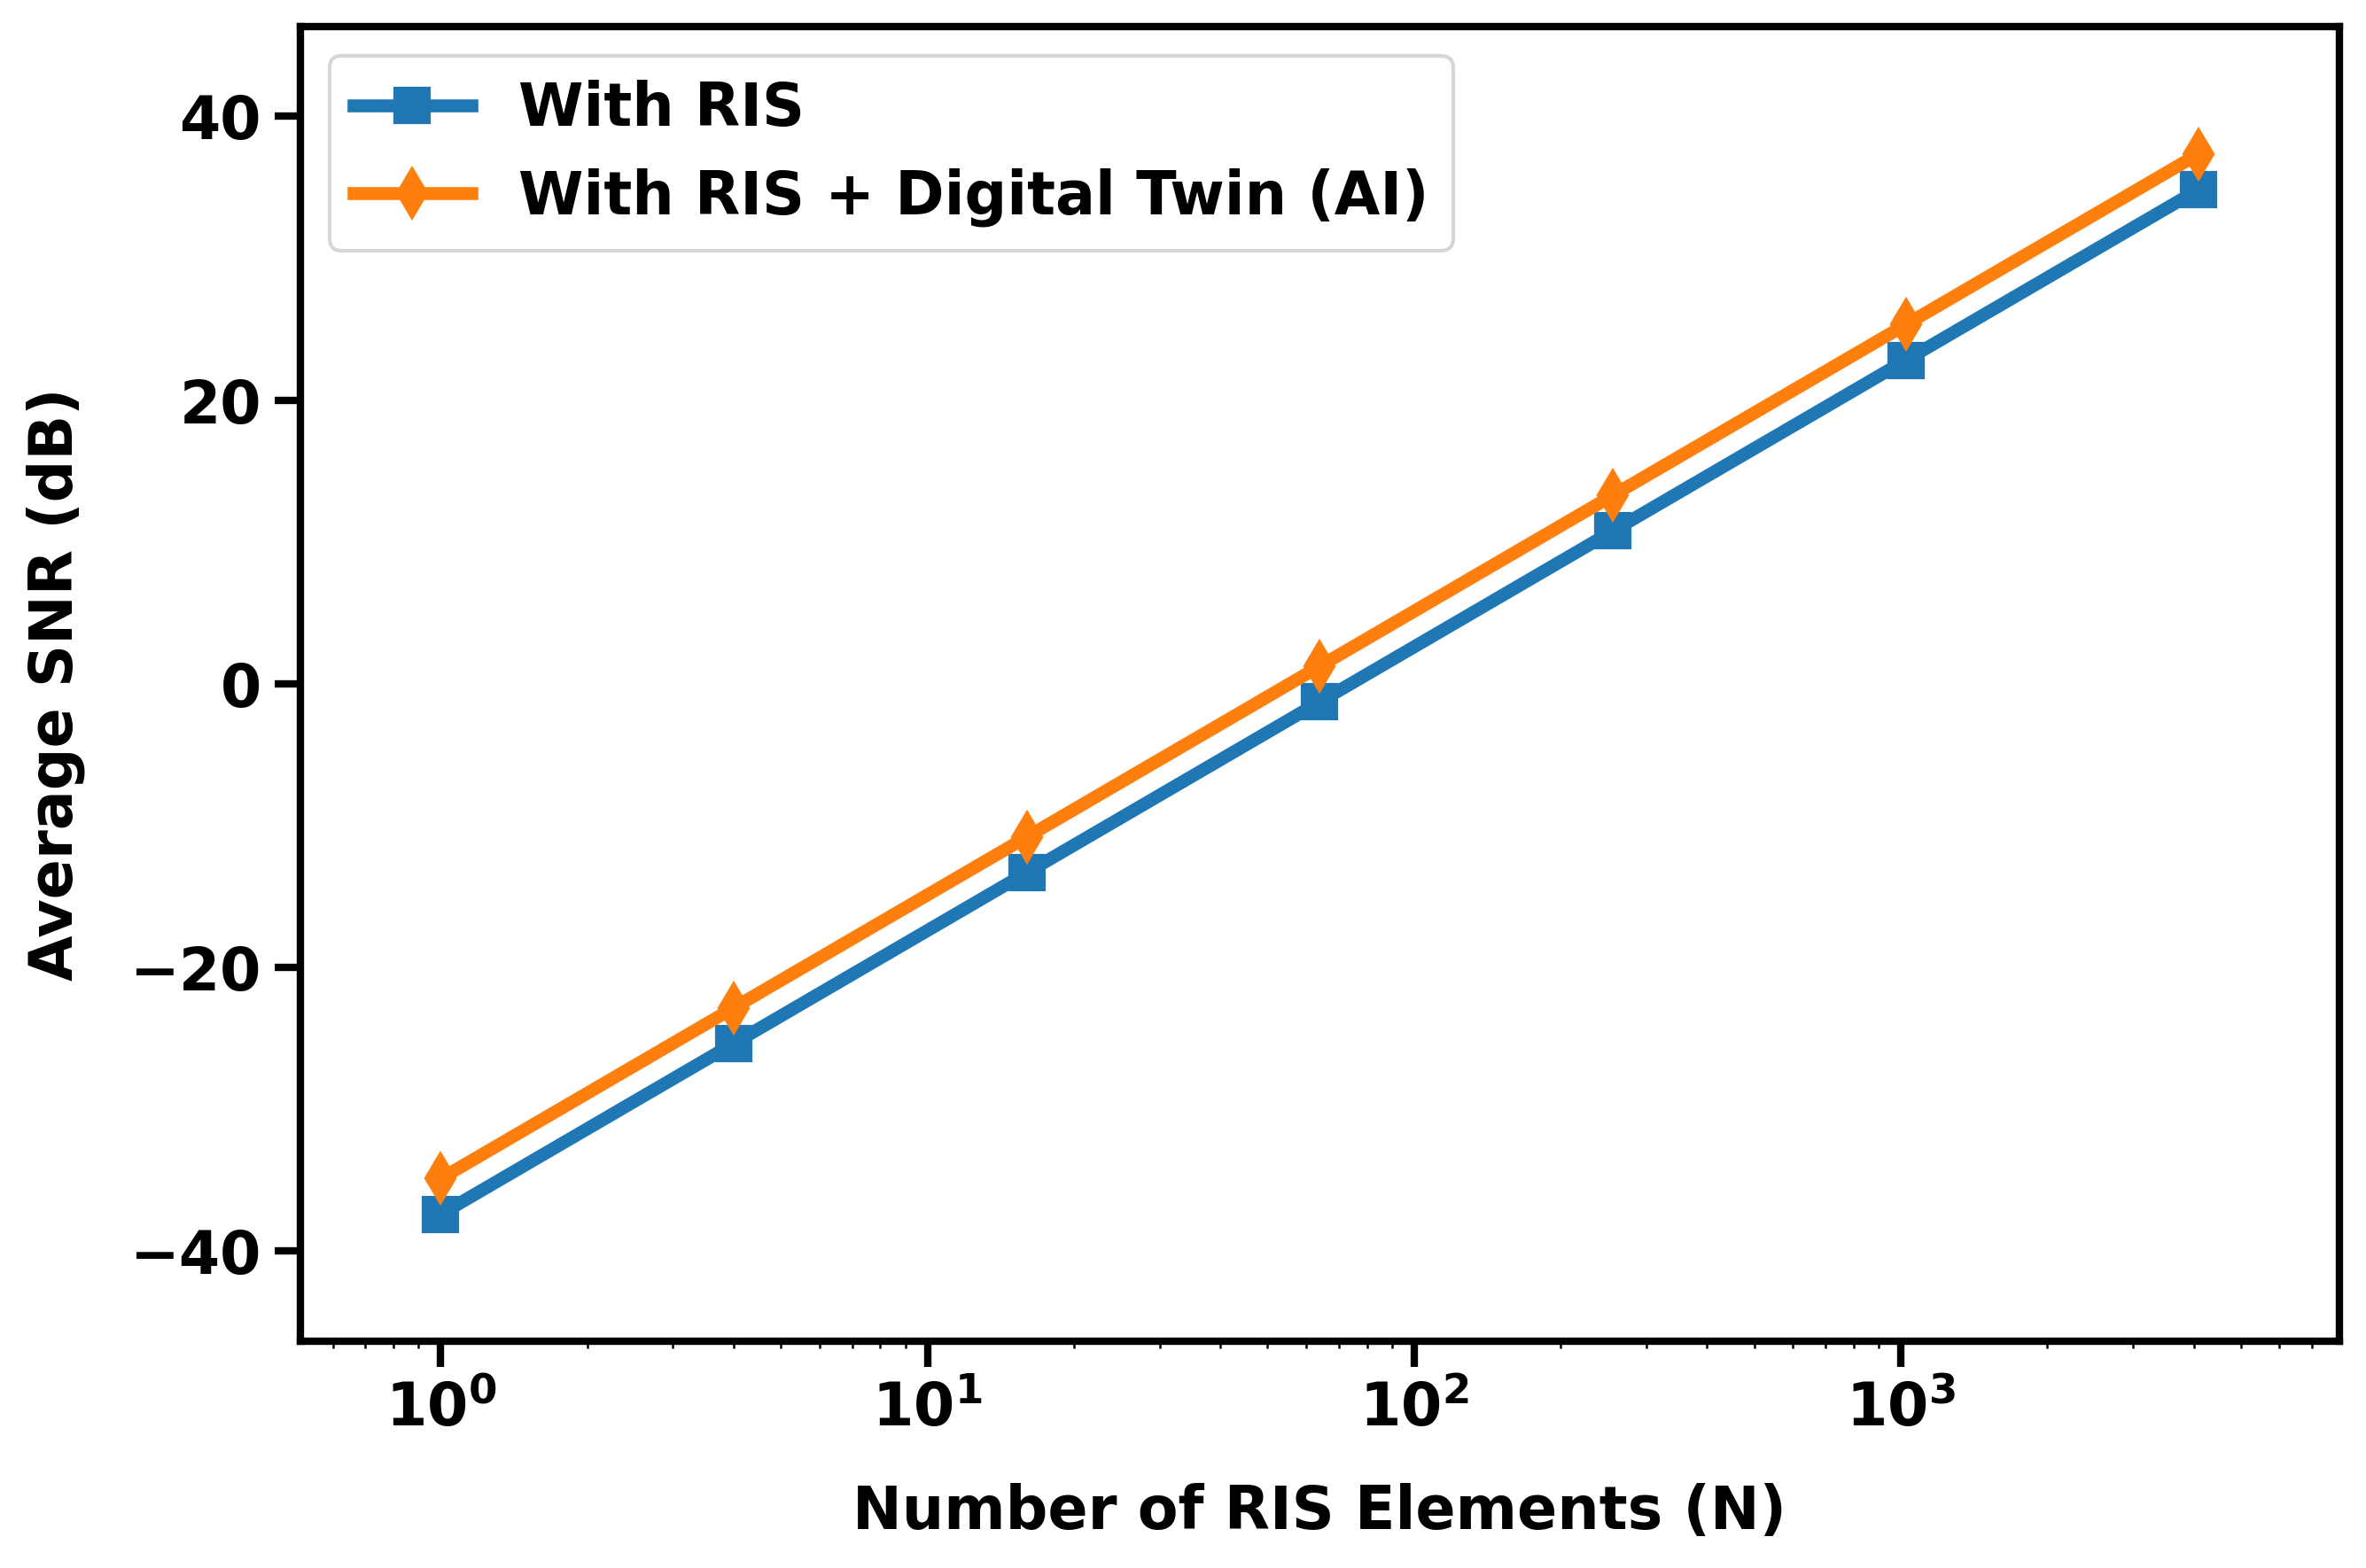

In [5]:
import numpy as np

import matplotlib.pyplot as plt



# --------------------------------------------------

# PARAMETERS

# --------------------------------------------------

c = 3e8

f = 140e9

lam = c / f



Pt_dbm = 20

Pt = 10 ** ((Pt_dbm - 30) / 10)



NF_db = 7

B = 1e9

k = 1.38e-23

T = 290



Noise = k * T * B * 10 ** (NF_db / 10)



d_tx = d_rx = 15



eta_ris = 0.8

eta_ai = 0.9



ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10)



# --------------------------------------------------

# FUNCTIONS

# --------------------------------------------------

def fspl(d):

    return (4 * np.pi * d / lam) ** 2



def pr_with_ris(Pt, d_tx, d_rx, N, eta):

    lam2 = lam ** 2

    return Pt * eta * (N ** 2) * (

        lam2 / ((4 * np.pi) ** 3 * d_tx ** 2 * d_rx ** 2)

    )



# --------------------------------------------------

# RIS configurations

# --------------------------------------------------

N_values = np.array([1, 4, 16, 64, 256, 1024, 4096])



snr_RIS = []

snr_AI = []



for N in N_values:



    p_RIS = pr_with_ris(Pt, d_tx, d_rx, N, eta_ris)



    p_AI = pr_with_ris(

        Pt,

        d_tx,

        d_rx,

        N,

        eta_ai

    ) * ai_gain_lin



    snr_RIS.append(10 * np.log10(p_RIS / Noise))

    snr_AI.append(10 * np.log10(p_AI / Noise))



# --------------------------------------------------

# HD RESEARCH PAPER LEVEL PLOT

# --------------------------------------------------

plt.figure(figsize=(9, 6), dpi=300)



plt.plot(

    N_values,

    snr_RIS,

    's-',

    label='With RIS',

    linewidth=3.5,

    markersize=9

)



plt.plot(

    N_values,

    snr_AI,

    'd-',

    label='With RIS + Digital Twin (AI)',

    linewidth=3.5,

    markersize=9

)



plt.xscale('log')



plt.xlabel(

    'Number of RIS Elements (N)',

    fontsize=16,

    fontweight='bold',

    labelpad=12

)



plt.ylabel(

    'Average SNR (dB)',

    fontsize=16,

    fontweight='bold',

    labelpad=12

)



plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(

    prop={'weight': 'bold', 'size': 16},

    loc='upper left',

    frameon=True

)



ax = plt.gca()



for spine in ax.spines.values():

    spine.set_linewidth(2)



ax.tick_params(width=2, length=7)



plt.margins(x=0.08, y=0.12)



plt.tight_layout()



plt.show()

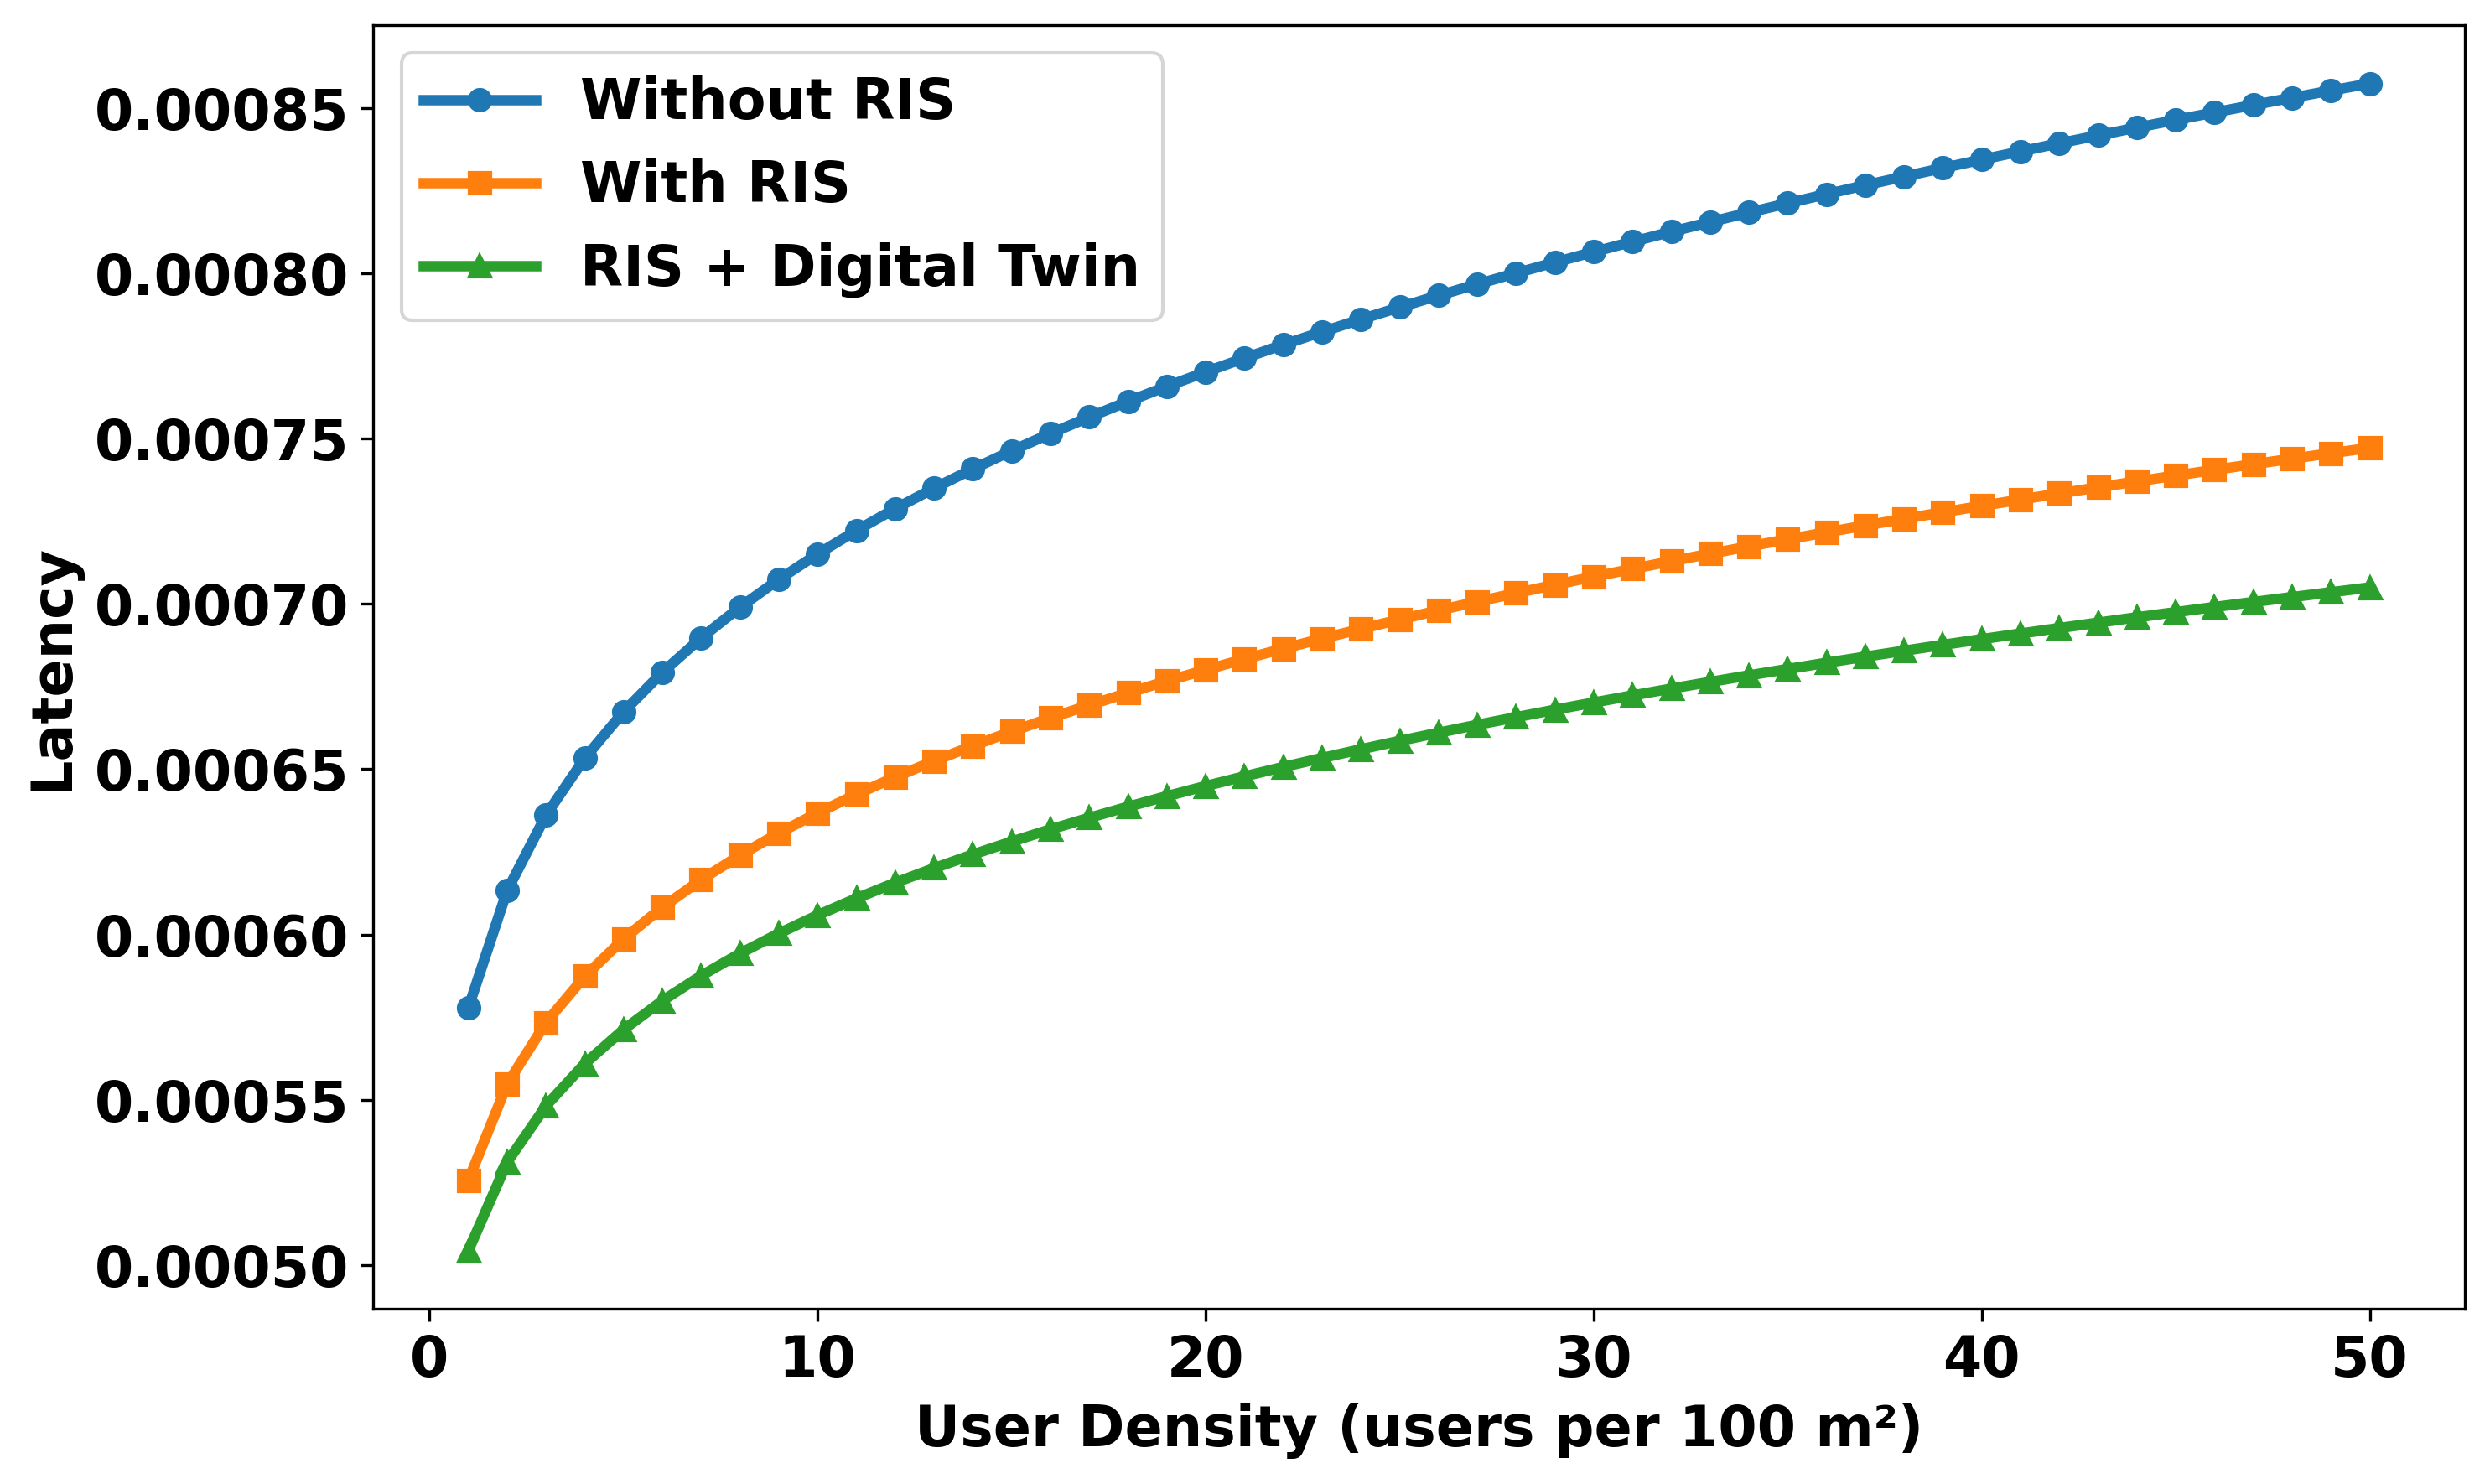

In [21]:
import numpy as np

import matplotlib.pyplot as plt



c = 299_792_458

k_B = 1.380649e-23

T0 = 290.0



f_c_thz = 0.0035

f_c = f_c_thz * 1e12

lam = c / f_c



B = 100e6

Pt_dbm = 23.0

Pt_w = 10 ** ((Pt_dbm - 30)/10)



G_rx_db = 15.0

G_rx_lin = 10 ** (G_rx_db / 10)

NF_db = 9.0

N0_w = k_B * T0 * 10 ** (NF_db/10) * B



N_ris = 1024

element_spacing = 0.05

eta_ris = 0.80



ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10)

eta_ai = 0.88



packet_size_bits = 1e6



def path_loss_db(d, f_hz):

    f_mhz = f_hz / 1e6

    N_LOS = 28

    return 20 * np.log10(f_mhz) + N_LOS * np.log10(d) - 28



def pr_direct(Pt, d, G_rx_lin, f_hz):

    pl_lin = 10 ** (path_loss_db(d, f_hz)/10)

    return Pt * G_rx_lin / pl_lin



def pr_ris_physical(Pt, d_tx_ris, d_ris_rx, G_tx=1.0, G_rx=G_rx_lin,

                    N_ris=1024, element_spacing=0.05, eta=1.0):

    A_elem = element_spacing**2

    A_eff = N_ris * A_elem * eta

    lam_local = c / f_c

    pl_linear = ((4 * np.pi * d_tx_ris / lam_local) * (4 * np.pi * d_ris_rx / lam_local))**2

    AF = 1.0

    pr = Pt * G_tx * G_rx * (A_eff / lam_local**2)**2 * AF / pl_linear

    return pr



def latency_from_snr(pr, N0, packet_bits, B):

    snr = pr / N0

    rate = B * np.log2(1 + snr)

    return packet_bits / rate



user_density = np.linspace(1, 50, 50)



SE_noRIS = []

SE_RIS = []

SE_RIS_AI = []



d_tx_ris = 5.0

d_ris_rx = 5.0

d_avg = 10.0



for U in user_density:

    Pt_eff = Pt_w / U



    pr0 = pr_direct(Pt_eff, d_avg, G_rx_lin, f_c)

    lat0 = latency_from_snr(pr0, N0_w, packet_size_bits, B)

    SE_noRIS.append(lat0)



    pr_r = pr_ris_physical(Pt_eff, d_tx_ris, d_ris_rx,

                            N_ris=N_ris,

                            element_spacing=element_spacing,

                            eta=eta_ris)

    lat_r = latency_from_snr(pr_r, N0_w, packet_size_bits, B)

    SE_RIS.append(lat_r)



    pr_ai = pr_r * ai_gain_lin * (eta_ai / eta_ris)

    lat_ai = latency_from_snr(pr_ai, N0_w, packet_size_bits, B)

    SE_RIS_AI.append(lat_ai)



plt.figure(figsize=(10, 6), dpi=300)



plt.plot(user_density, SE_noRIS, label='Without RIS', linewidth=3, marker="o", markersize=6)

plt.plot(user_density, SE_RIS, label='With RIS', linewidth=3, marker="s", markersize=6)

plt.plot(user_density, SE_RIS_AI, label='RIS + Digital Twin', linewidth=3, marker="^", markersize=6)



plt.xlabel('User Density (users per 100 m²)', fontsize=16, fontweight='bold')

plt.ylabel('Latency', fontsize=16, fontweight='bold')



plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(prop={'weight': 'bold', 'size': 16})



plt.tight_layout()

plt.show()

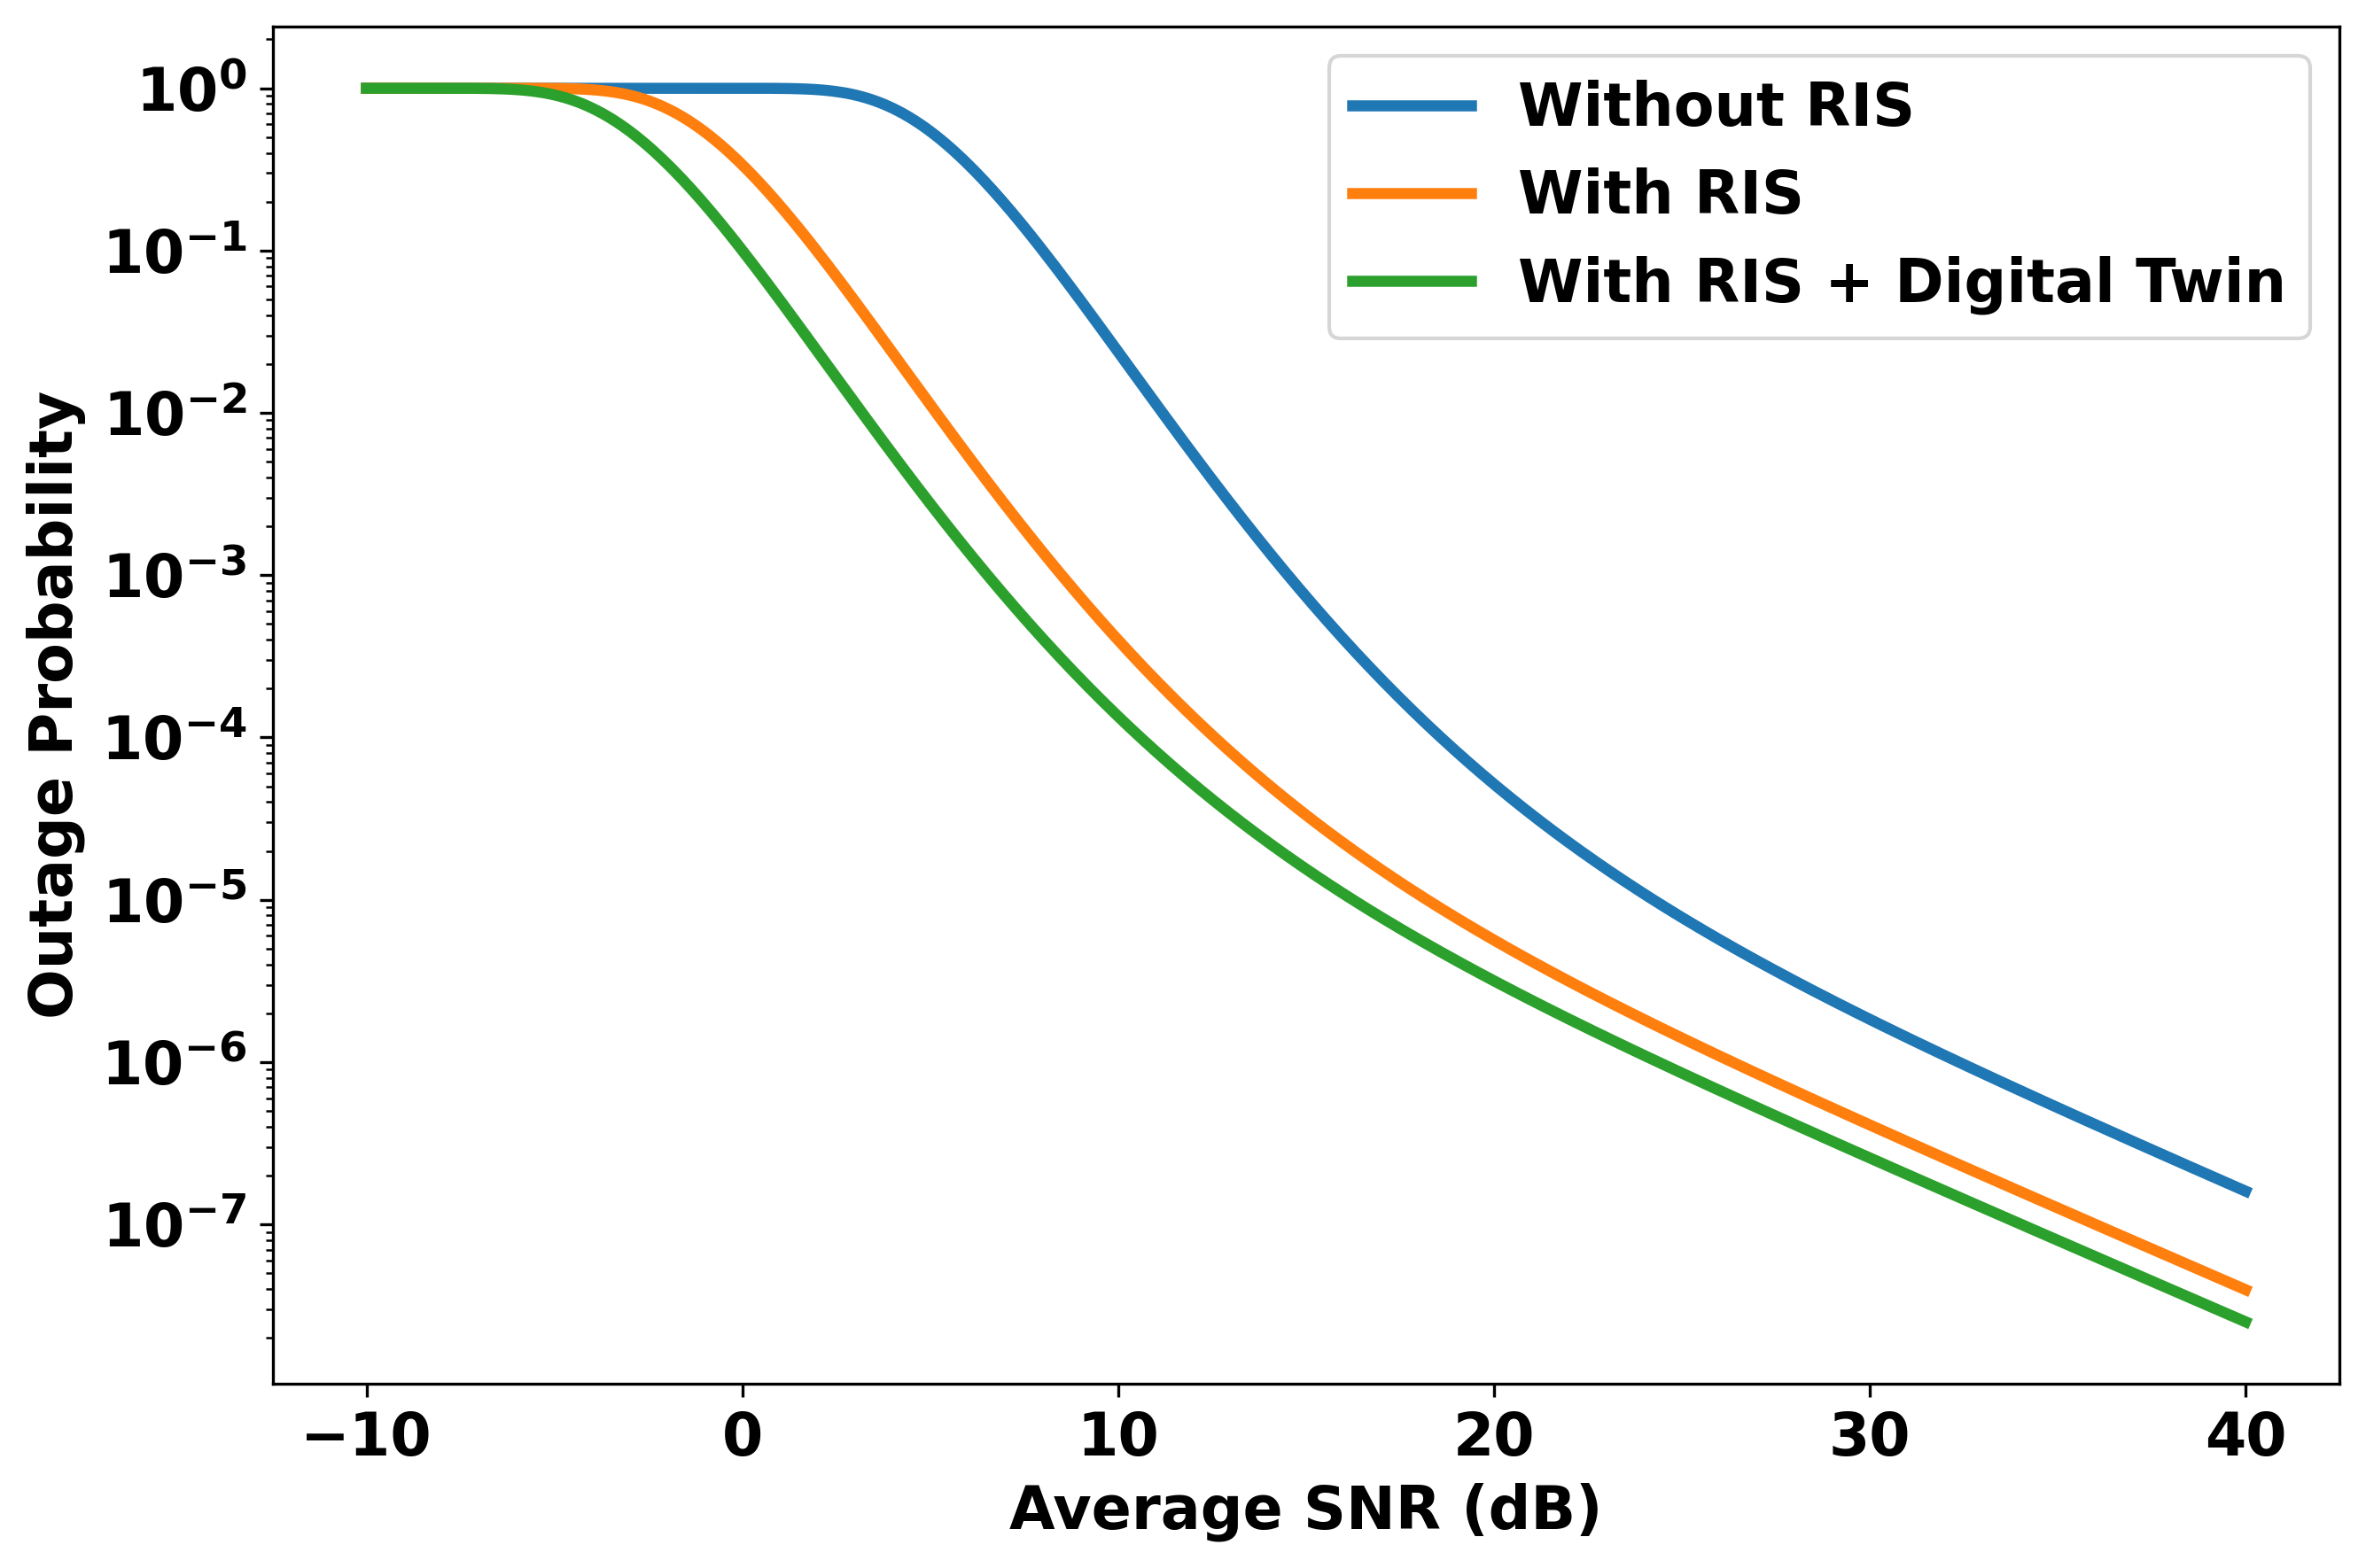

In [22]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import ncx2



# -------------------------------------------------------

# PARAMETERS

# -------------------------------------------------------

K_dB = 10

K = 10 ** (K_dB / 10)



snr_db = np.linspace(-10, 40, 400)

snr_lin = 10 ** (snr_db / 10)



snr_th_db = 5

snr_th_lin = 10 ** (snr_th_db / 10)



# -------------------------------------------------------

# OUTAGE PROBABILITY

# -------------------------------------------------------

def rician_outage_exact(avg_snr, K, snr_th):

    v = 2

    nc = 2 * K

    x = 2 * (K + 1) * snr_th / avg_snr

    return ncx2.cdf(x, v, nc)



# -------------------------------------------------------

# COMPUTE OUTAGE CURVES

# -------------------------------------------------------

p_noRIS = rician_outage_exact(snr_lin, K, snr_th_lin)



gain_RIS = 4.0

gain_AI = 6.3



p_RIS = rician_outage_exact(snr_lin * gain_RIS, K, snr_th_lin)

p_AI = rician_outage_exact(snr_lin * gain_AI, K, snr_th_lin)



# -------------------------------------------------------

# HD RESEARCH PAPER LEVEL PLOT

# -------------------------------------------------------

plt.figure(figsize=(9, 6), dpi=300)



plt.semilogy(snr_db, p_noRIS, label='Without RIS', linewidth=3)

plt.semilogy(snr_db, p_RIS, label='With RIS', linewidth=3)

plt.semilogy(snr_db, p_AI, label='With RIS + Digital Twin', linewidth=3)



plt.xlabel('Average SNR (dB)', fontsize=16, fontweight='bold')

plt.ylabel('Outage Probability', fontsize=16, fontweight='bold')



plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')

plt.legend(prop={'weight': 'bold', 'size': 16})



plt.tight_layout()

plt.show()

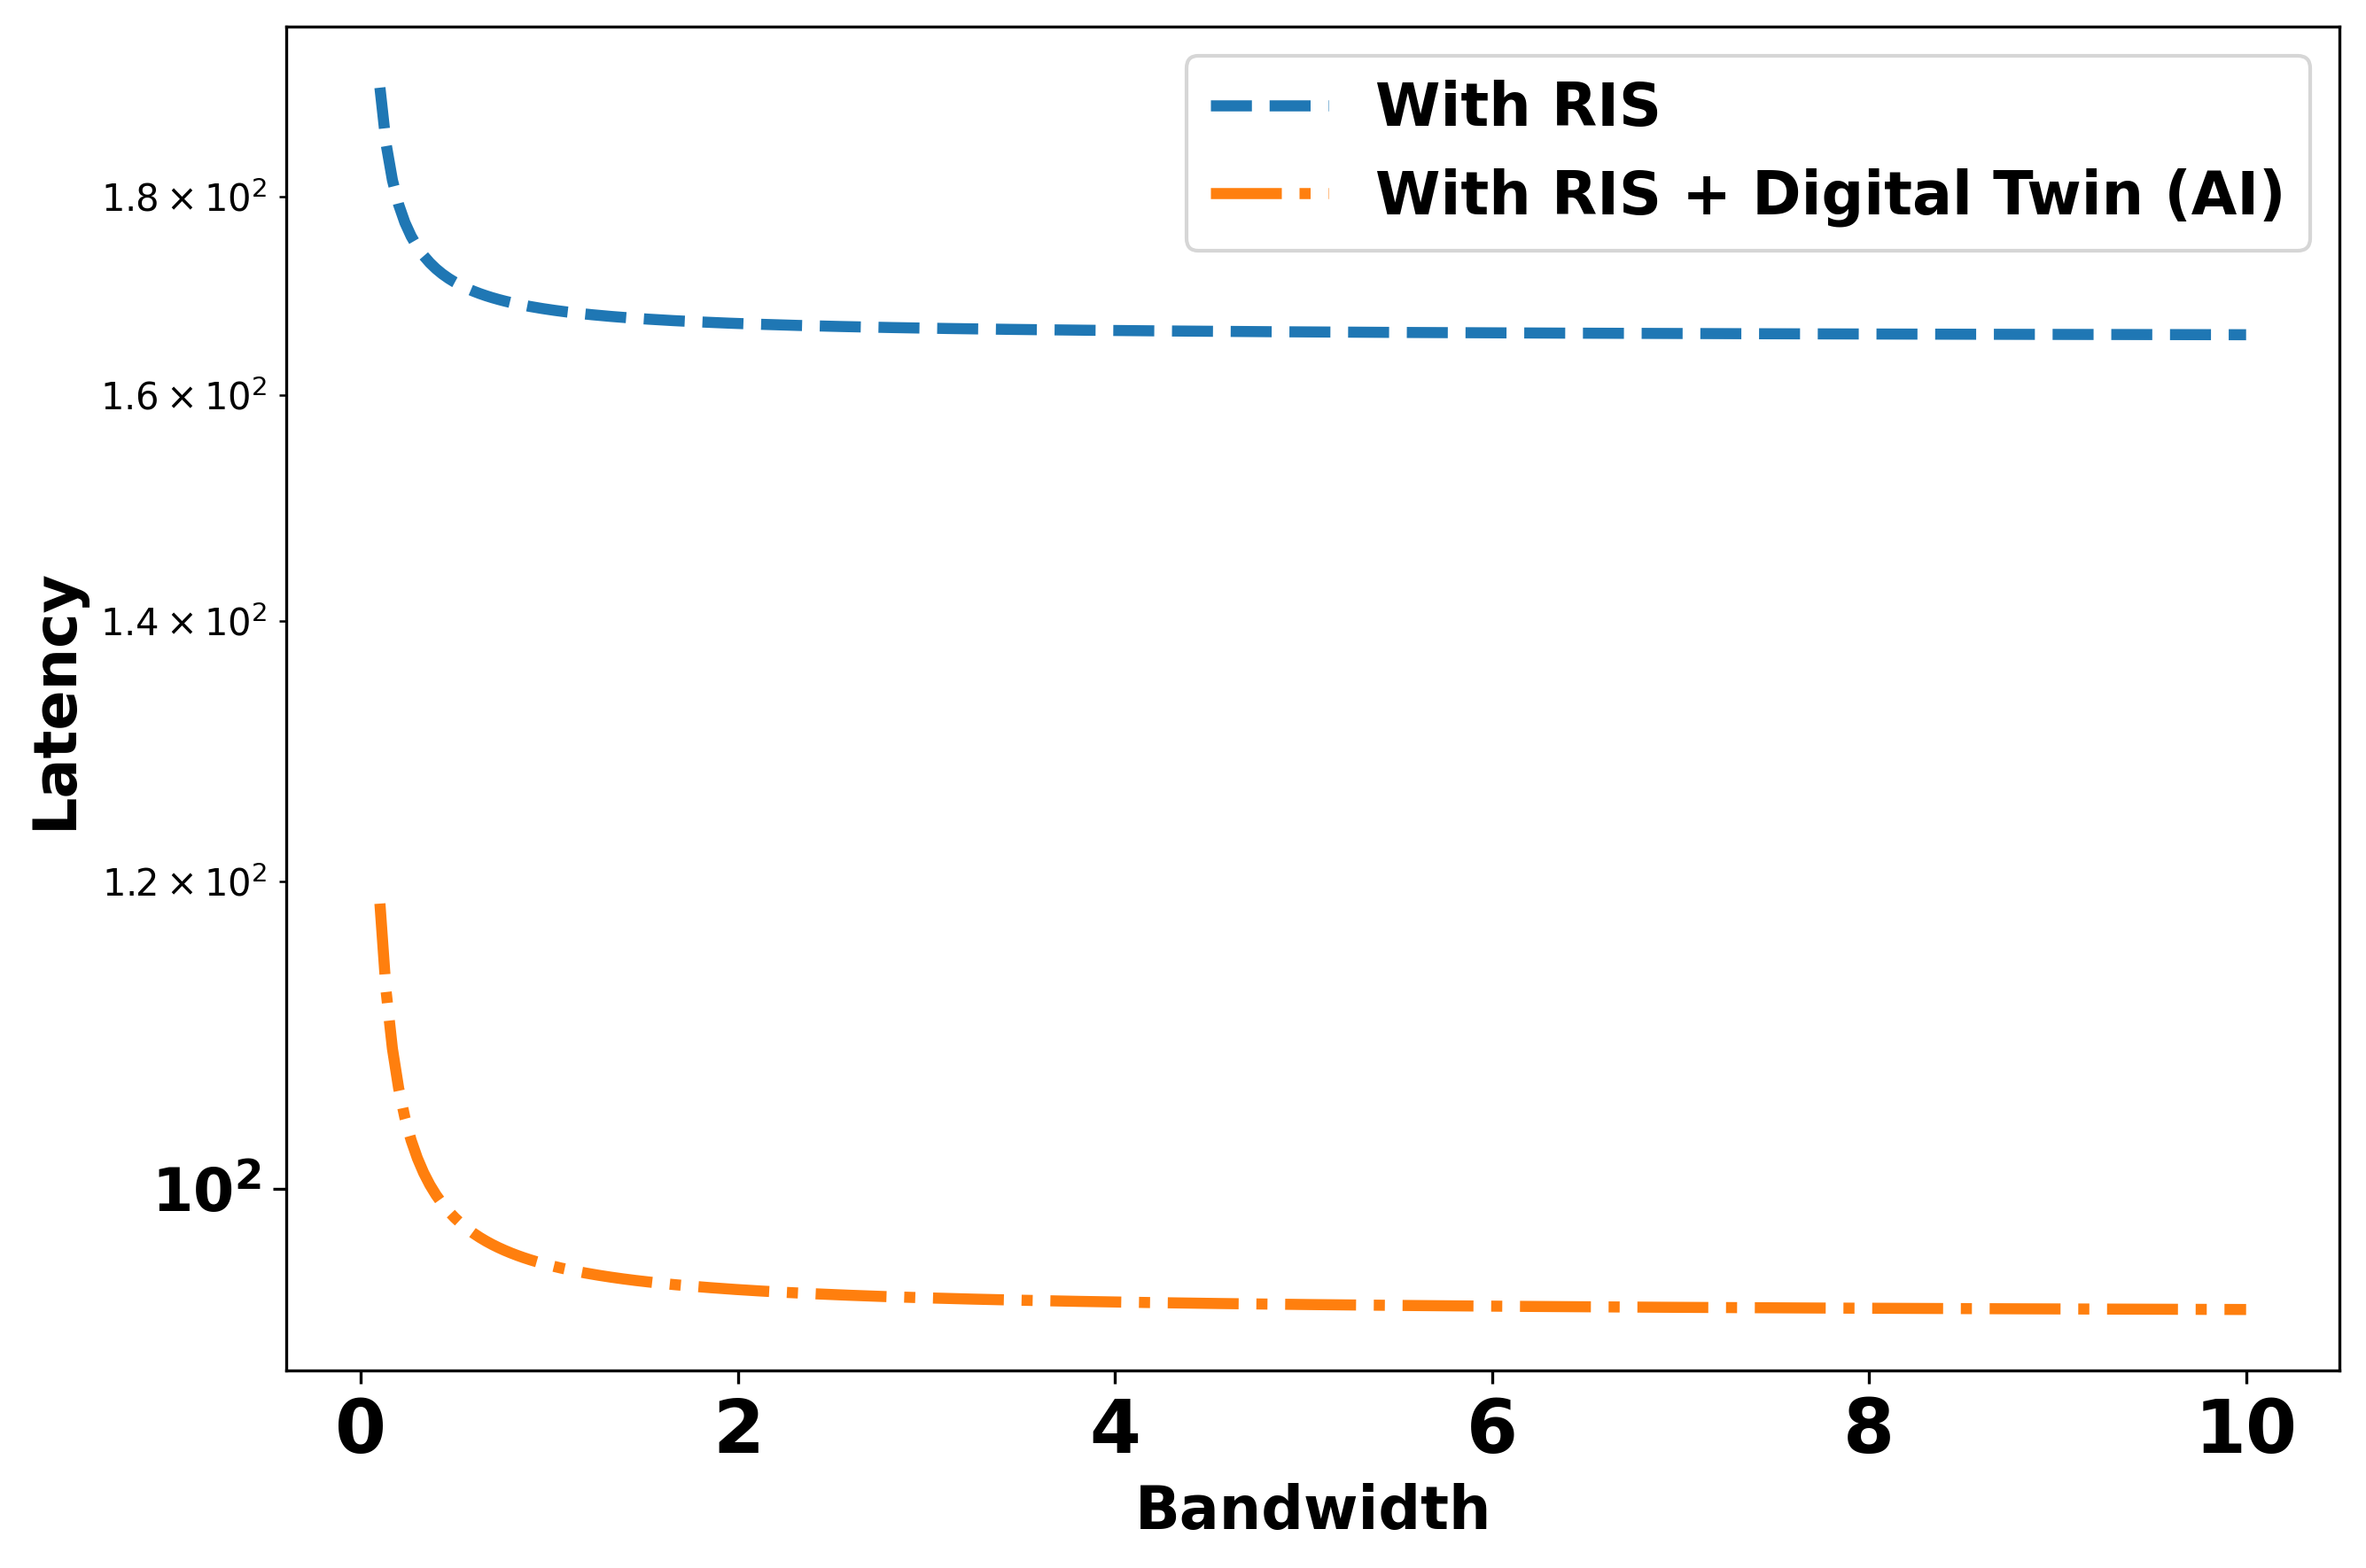

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import itur

import astropy.units as u



# ---------------------------------------------------------

# CONSTANTS AND SYSTEM PARAMETERS

# ---------------------------------------------------------

c = 3e8

f = 1e12

lam = c / f



Pt_dBm = 20

Pt = 10 ** ((Pt_dBm - 30) / 10)



NF_dB = 7

B = np.linspace(1e8, 1e10, 300)



k = 1.38064852e-23

T = 290



d_tx = 15

d_rx = 15

d_total = d_tx + d_rx



eta_ris = 0.8

eta_ai = 0.9



ai_gain_dB = 2.0

ai_gain_lin = 10 ** (ai_gain_dB / 10)



packet_size_bits = 8e6



# ---------------------------------------------------------

# TRUE ATMOSPHERIC ATTENUATION

# ---------------------------------------------------------

def gaseous_loss_linear(distance_m, freq_ghz, P_hpa=1013.25, T_k=290, rho_g_m3=7.5):

    el_deg = 90 * u.deg

    r_km = (distance_m / 1000.0) * u.km

    f_ghz = freq_ghz * u.GHz



    A_gas_db = itur.models.itu676.gaseous_attenuation_terrestrial_path(

        r_km,

        f_ghz,

        el_deg,

        rho_g_m3,

        P_hpa,

        T_k,

        mode='exact'

    )



    A_gas_db_value = A_gas_db.to(u.dB).value

    linear_factor = 10 ** (-A_gas_db_value / 10.0)



    return linear_factor



# ---------------------------------------------------------

# FREE SPACE PATH LOSS

# ---------------------------------------------------------

def fspl_linear(d):

    return (4 * np.pi * d / lam) ** 2



# ---------------------------------------------------------

# RECEIVED POWER CALCULATIONS

# ---------------------------------------------------------

def pr_no_ris(Pt, d_total, freq_ghz):

    L_fspl = fspl_linear(d_total)

    atm_loss = gaseous_loss_linear(d_total, freq_ghz)

    return Pt * atm_loss / L_fspl



def pr_with_ris(Pt, d_tx, d_rx, N, eta, freq_ghz):

    atm_tx = gaseous_loss_linear(d_tx, freq_ghz)

    atm_rx = gaseous_loss_linear(d_rx, freq_ghz)



    lam2 = lam ** 2



    Pr = Pt * eta * (N ** 2) * lam2 / (

        (4 * np.pi) ** 3 * d_tx ** 2 * d_rx ** 2

    )



    Pr = Pr * atm_tx * atm_rx



    return Pr



# ---------------------------------------------------------

# NOISE POWER

# ---------------------------------------------------------

def noise_power(B, NF_dB):

    return k * T * B * (10 ** (NF_dB / 10))



# ---------------------------------------------------------

# CALCULATE LATENCY

# ---------------------------------------------------------

freq_ghz = f / 1e9

N = 1024



p_noRIS = pr_no_ris(Pt, d_total, freq_ghz)

p_RIS = pr_with_ris(Pt, d_tx, d_rx, N, eta_ris, freq_ghz)

p_AI = pr_with_ris(Pt, d_tx, d_rx, N, eta_ai, freq_ghz) * ai_gain_lin



Noise = noise_power(B, NF_dB)



snr_noRIS = p_noRIS / Noise

snr_RIS = p_RIS / Noise

snr_AI = p_AI / Noise



R_noRIS = B * np.log2(1 + snr_noRIS)

R_RIS = B * np.log2(1 + snr_RIS)

R_AI = B * np.log2(1 + snr_AI)



lat_noRIS = packet_size_bits / R_noRIS

lat_RIS = packet_size_bits / R_RIS

lat_AI = packet_size_bits / R_AI



# ---------------------------------------------------------

# HD RESEARCH PAPER LEVEL PLOT

# ---------------------------------------------------------

plt.figure(figsize=(9, 6), dpi=300)



plt.semilogy(

    B / 1e9,

    lat_RIS * 1e3,

    label='With RIS',

    linewidth=3,

    linestyle='--'

)



plt.semilogy(

    B / 1e9,

    lat_AI * 1e3,

    label='With RIS + Digital Twin (AI)',

    linewidth=3,

    linestyle='-.'

)



plt.xlabel('Bandwidth', fontsize=16, fontweight='bold')

plt.ylabel('Latency', fontsize=16, fontweight='bold')


plt.xticks(fontsize=20, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(

    prop={'weight': 'bold', 'size': 16},

    loc='upper right'

)



plt.tight_layout()

plt.show()

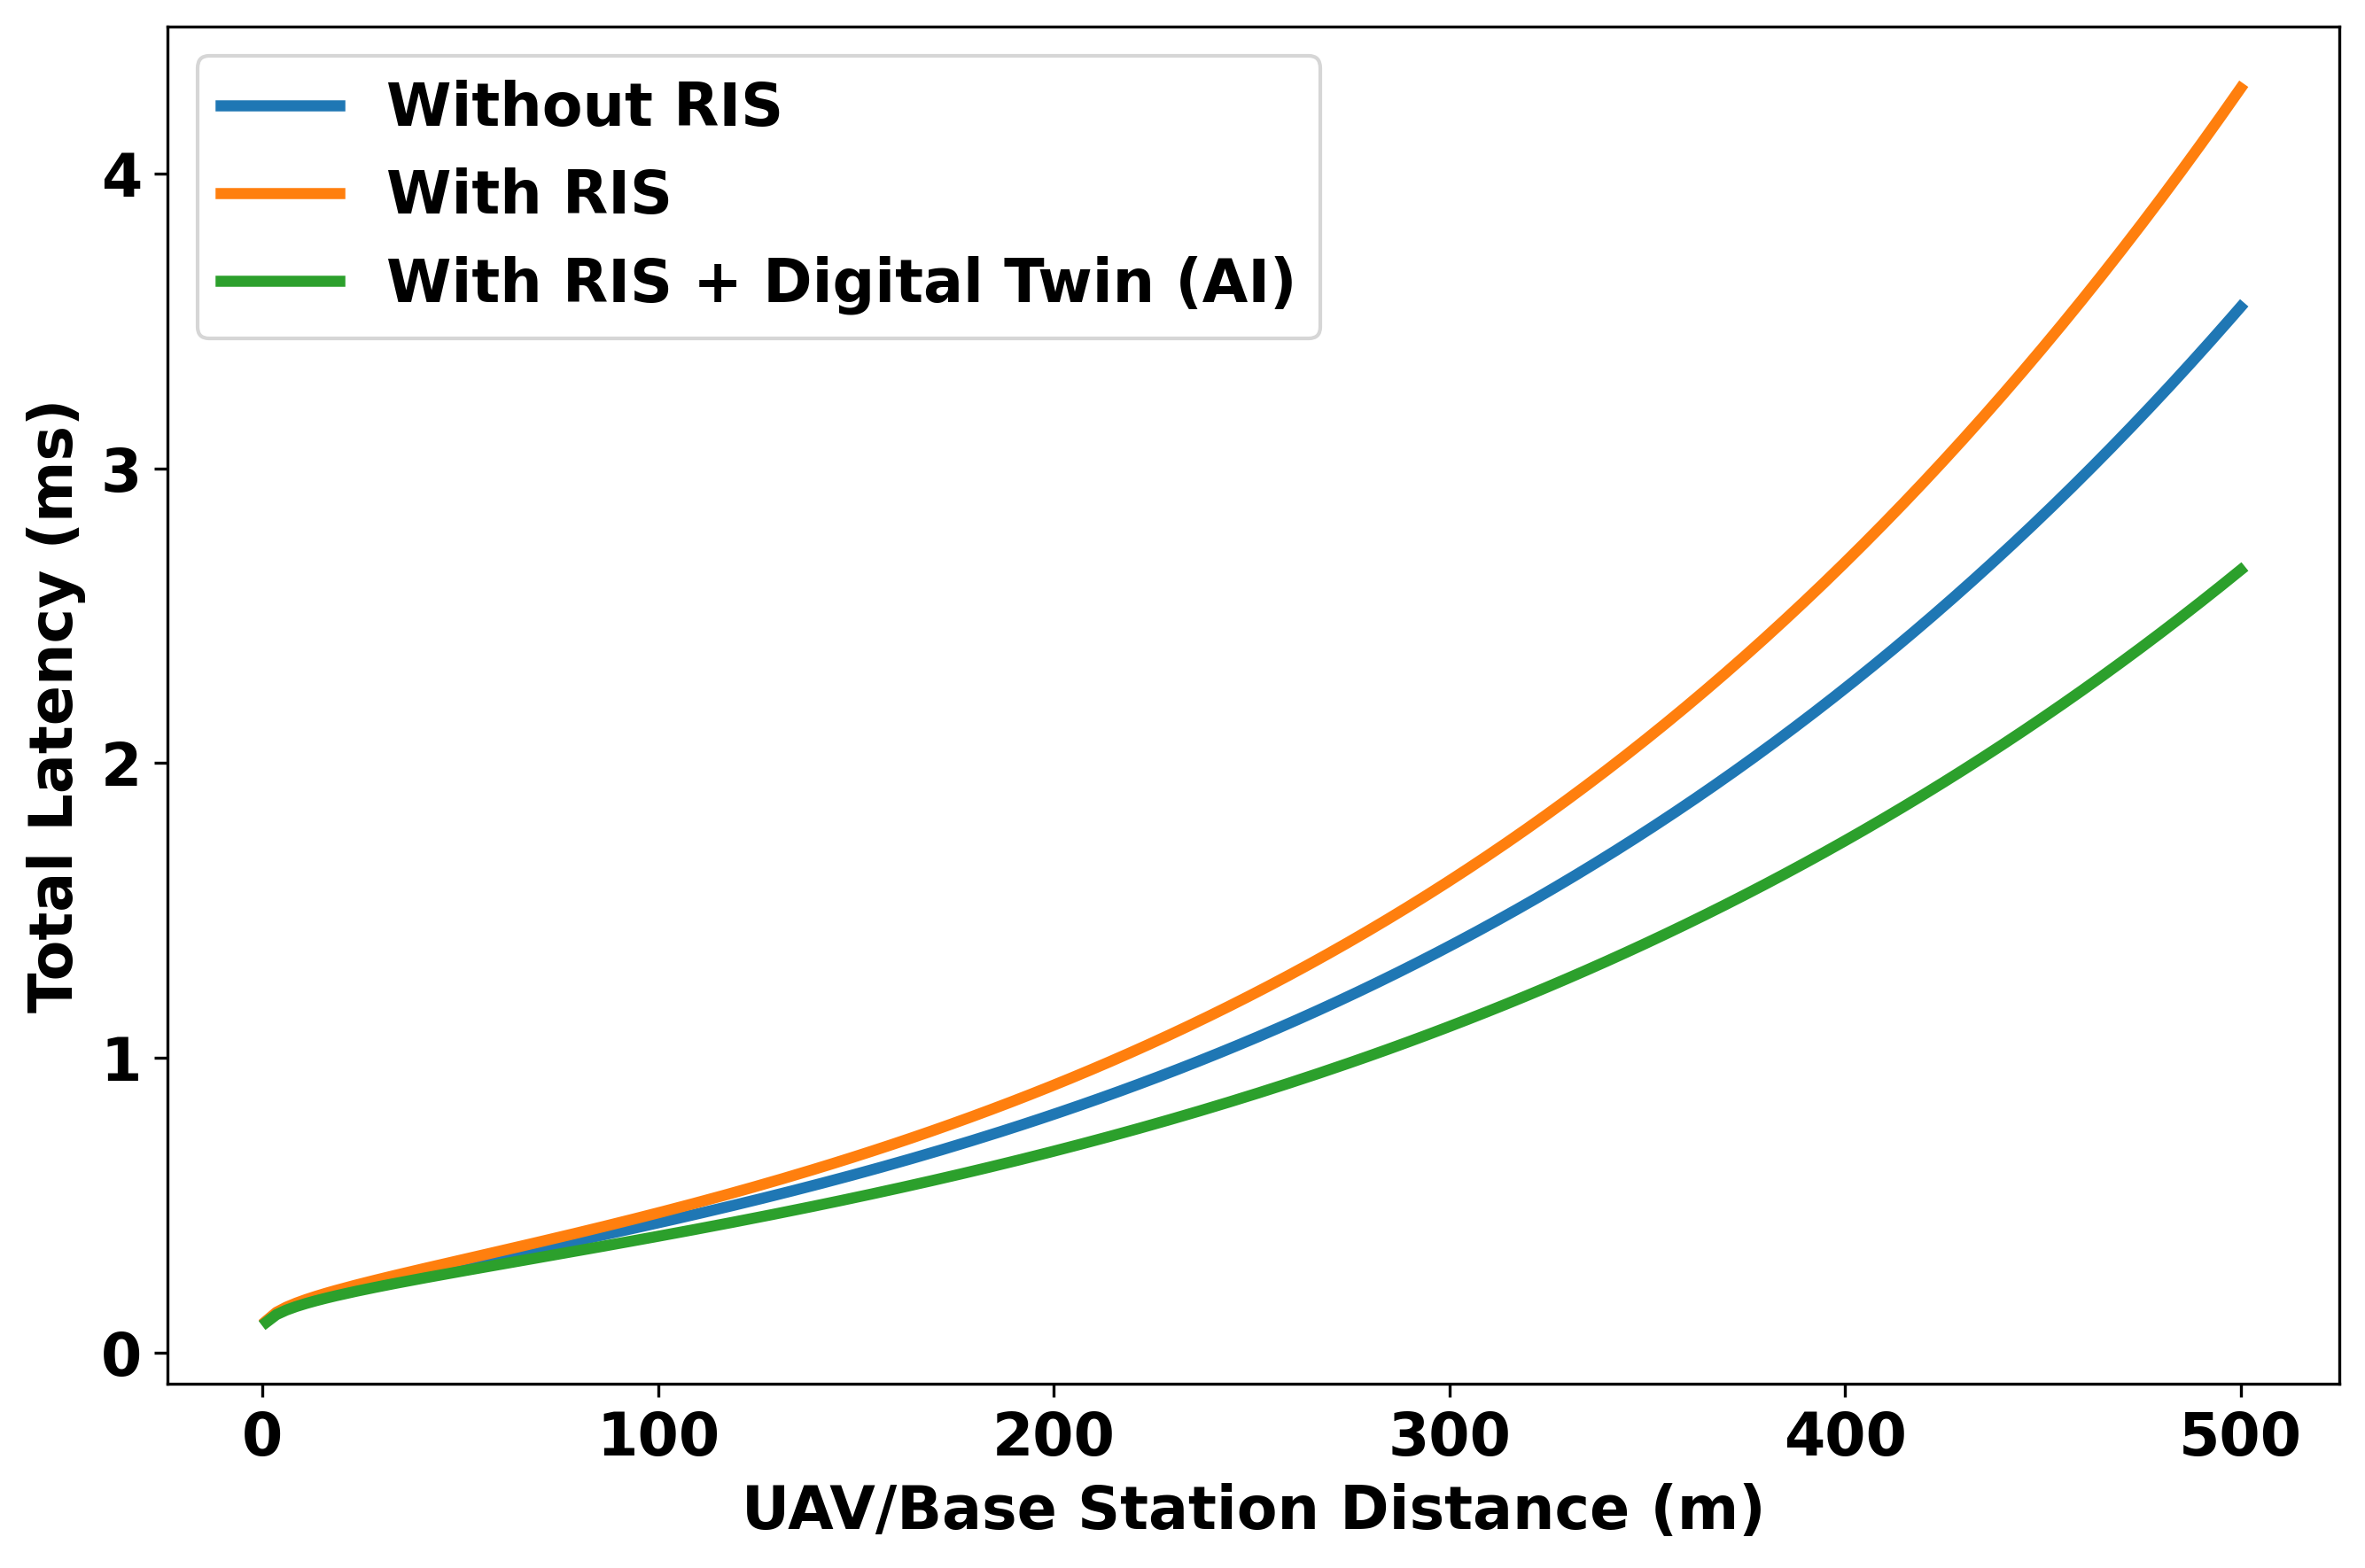

In [24]:
import numpy as np

import matplotlib.pyplot as plt



# ------------------------------------------------------

# CONSTANTS

# ------------------------------------------------------

c = 3e8

f = 300e9

lam = c / f

k = 1.380649e-23

T = 290

NF_db = 9.56

NF = 10 ** (NF_db / 10)

B = 4.32e9

Pt_dbm = 21.9

Pt = 10 ** ((Pt_dbm - 30) / 10)

Gt = 10 ** (25 / 10)

Gr = 10 ** (20 / 10)

L_bits = 8e6



alpha_db_per_km = 5.2

alpha_db_per_m = alpha_db_per_km / 1000



eta_ris = 0.8

eta_ai = 0.9

ai_gain_db = 2

ai_gain_lin = 10 ** (ai_gain_db / 10)



# ------------------------------------------------------

# FUNCTIONS

# ------------------------------------------------------

def fspl(d):

    return (4 * np.pi * d / lam) ** 2



def gaseous_loss(d):

    return 10 ** (-(alpha_db_per_m * d) / 10)



def received_power(Pt, d, Gt, Gr):

    return Pt * Gt * Gr * gaseous_loss(d) / fspl(d)



def latency(Pt, d, Gt, Gr, eta=1.0, gain_lin=1.0):

    Pr = received_power(Pt, d, Gt, Gr) * eta * gain_lin

    Noise = k * T * B * NF

    snr_lin = Pr / Noise

    data_rate = B * np.log2(1 + snr_lin)

    t_tx = L_bits / data_rate

    t_prop = d / c

    return (t_tx + t_prop) * 1e3



# ------------------------------------------------------

# DISTANCE SWEEP

# ------------------------------------------------------

d = np.linspace(1, 500, 200)



lat_noRIS = [latency(Pt, dist, Gt, Gr) for dist in d]

lat_RIS = [latency(Pt, dist, Gt, Gr, eta_ris) for dist in d]

lat_AI = [latency(Pt, dist, Gt, Gr, eta_ai, ai_gain_lin) for dist in d]



# ------------------------------------------------------

# HD RESEARCH PAPER LEVEL PLOT

# ------------------------------------------------------

plt.figure(figsize=(9, 6), dpi=300)



plt.plot(d, lat_noRIS, label='Without RIS', linewidth=3)

plt.plot(d, lat_RIS, label='With RIS', linewidth=3)

plt.plot(d, lat_AI, label='With RIS + Digital Twin (AI)', linewidth=3)



plt.xlabel('UAV/Base Station Distance (m)', fontsize=16, fontweight='bold')

plt.ylabel('Total Latency (ms)', fontsize=16, fontweight='bold')

plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(prop={'weight': 'bold', 'size': 16})



plt.tight_layout()

plt.show()

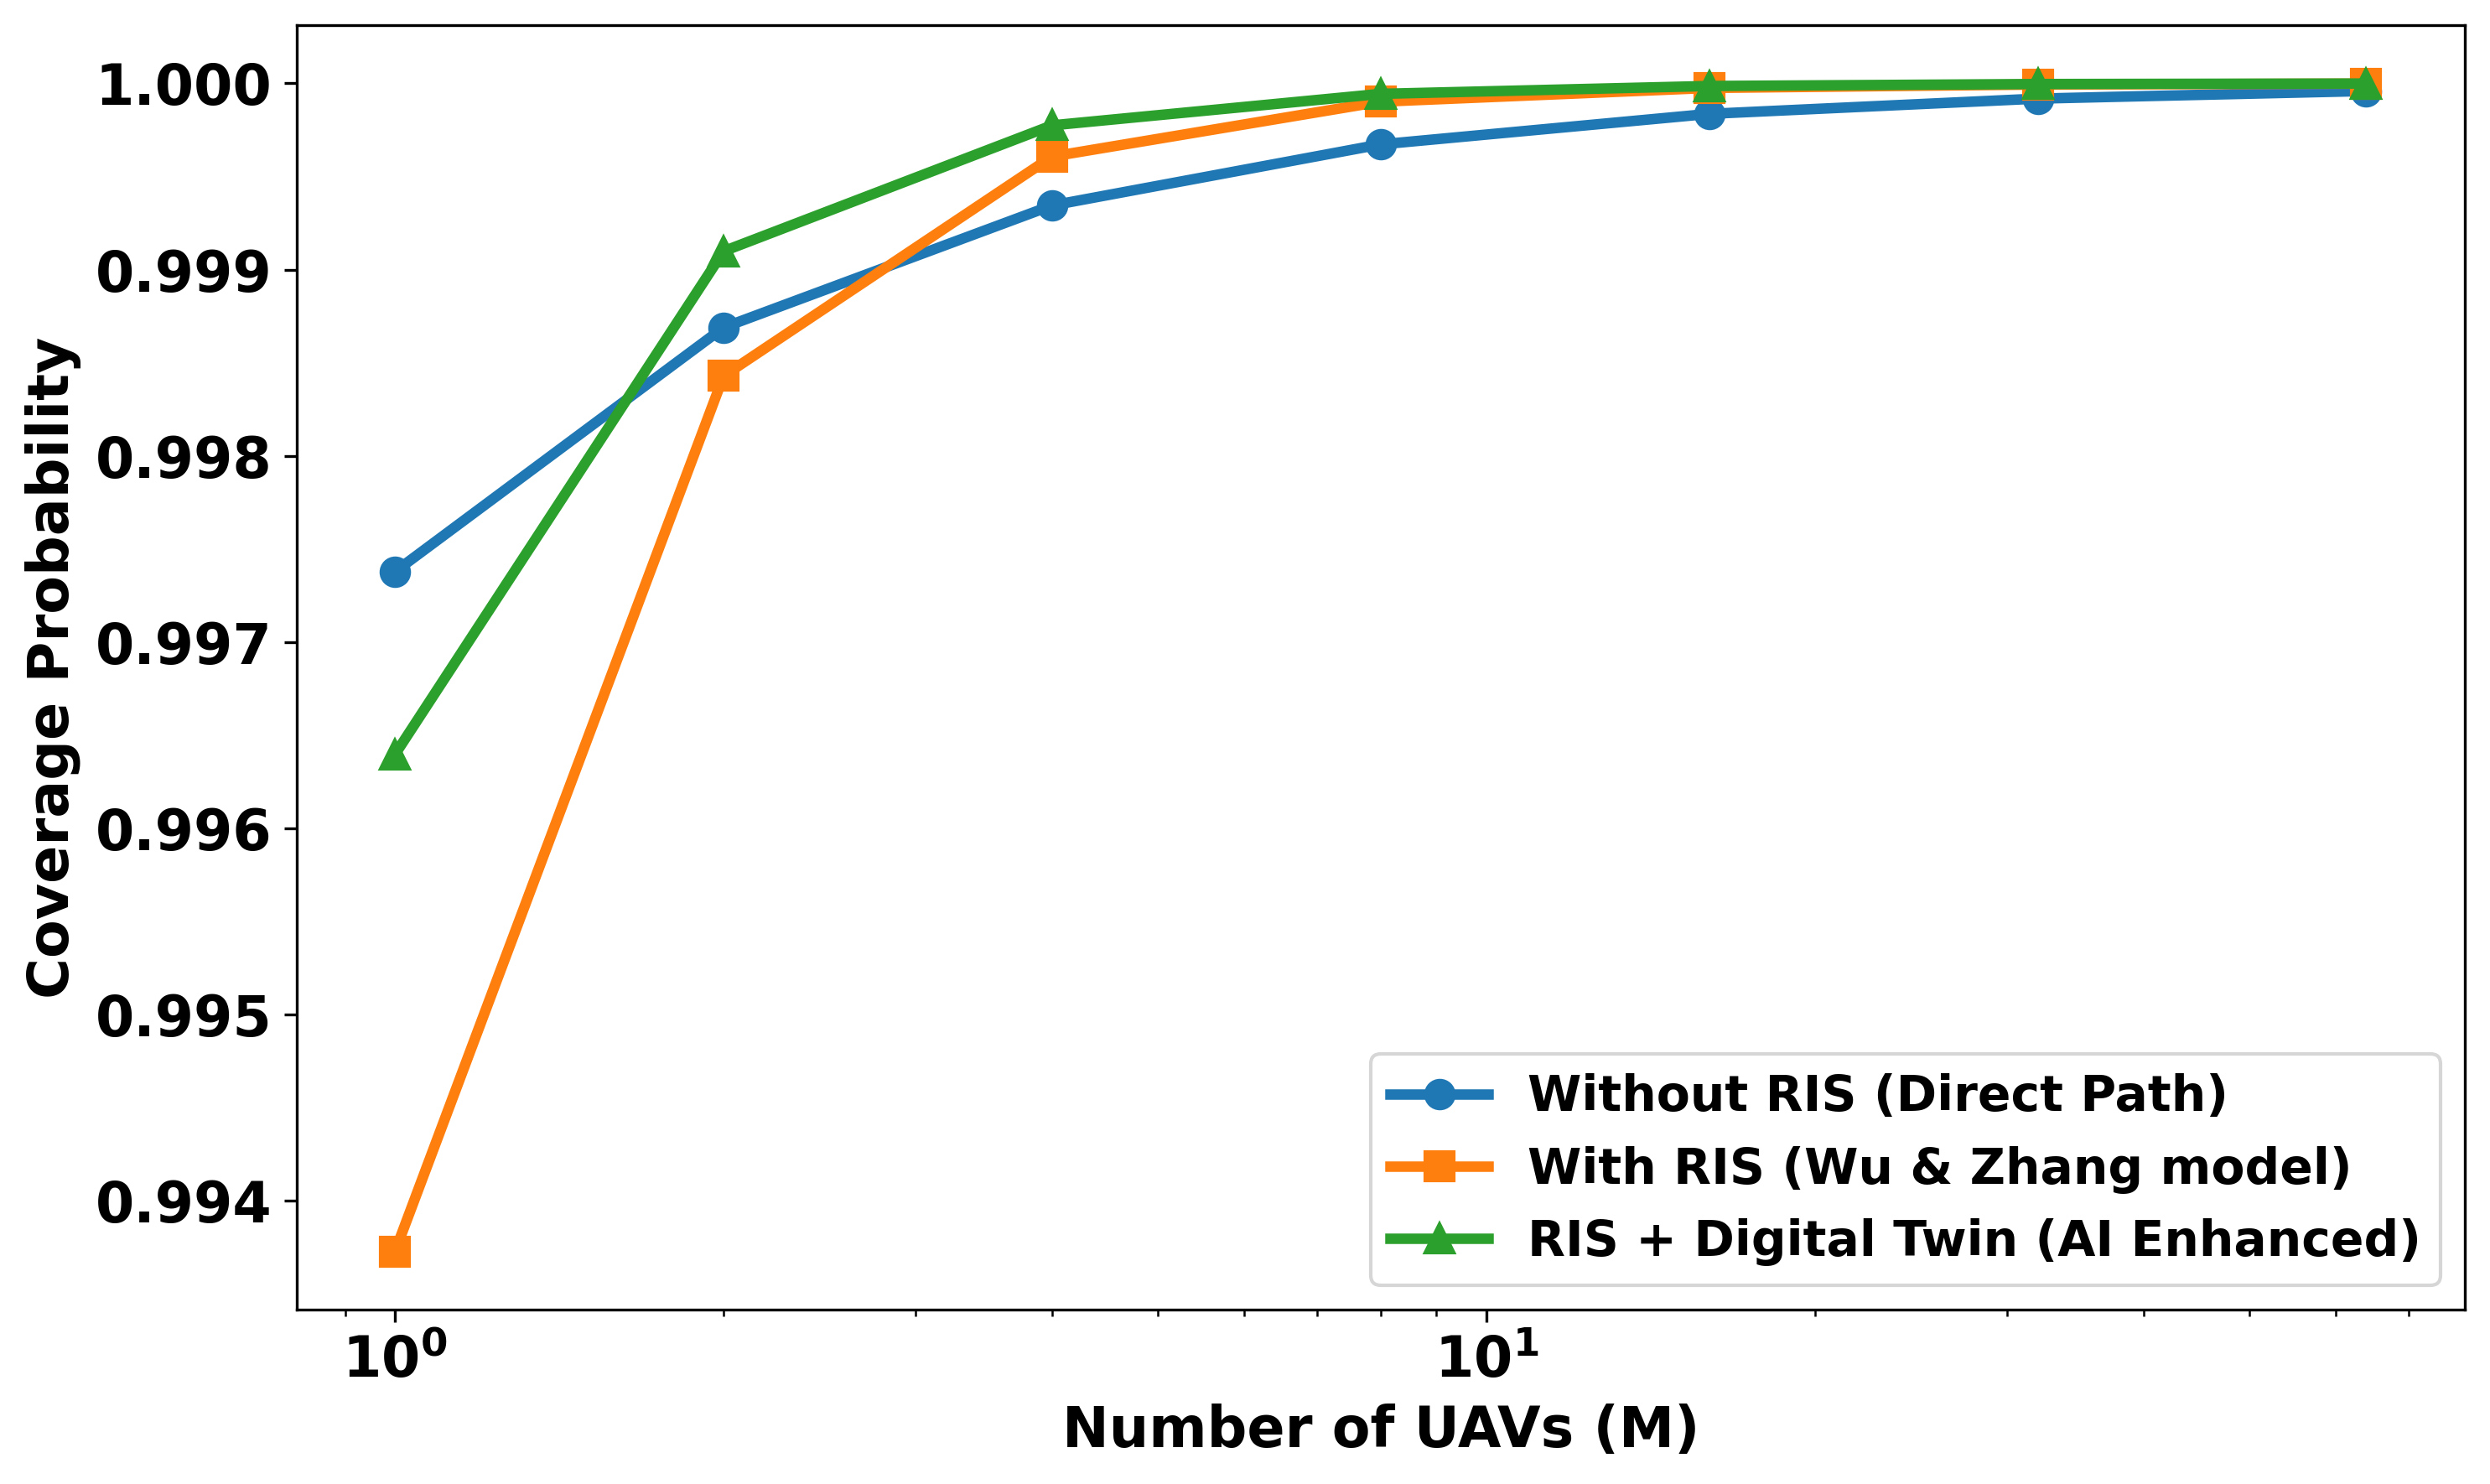

In [25]:
import numpy as np

import matplotlib.pyplot as plt

import math



# ==========================================================

# 1) Constants and literature-based parameters

# ==========================================================



c = 3e8

f_c = 28e9

lam = c / f_c

alpha_db_per_km = 0.1

alpha_db_per_m = alpha_db_per_km / 1000.0



Pt_dbm = 30

Pt_w = 10 ** ((Pt_dbm - 30) / 10)



G_rx_db = 15.0

G_rx_lin = 10 ** (G_rx_db / 10)



NF_db = 7.0

k_B = 1.380649e-23

T0 = 290.0

B = 100e6

N0_w = k_B * T0 * (10 ** (NF_db / 10)) * B



eta_ris = 0.8

eta_ai = 0.88

ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10.0)



# ==========================================================

# 2) Channel & propagation models

# ==========================================================



def gaseous_loss_linear(d):

    return 10 ** (-(alpha_db_per_m * d) / 10.0)



def pr_direct(Pt_w, d, G_rx_lin):

    fspl = (4 * math.pi * d / lam) ** 2

    gas = gaseous_loss_linear(d)

    return Pt_w * G_rx_lin / fspl * gas



def pr_ris(Pt_w, d, N, lam, eta, G_rx_lin):

    num = Pt_w * G_rx_lin * (N ** 2) * (lam ** 2) * eta

    denom = (4 * math.pi) ** 3 * (d ** 4)

    return num / denom * gaseous_loss_linear(d)



# ==========================================================

# 3) Sweep number of UAVs (M) and compute coverage probability

# ==========================================================



M_values = np.array([1, 2, 4, 8, 16, 32, 64])

P_cov_noRIS = []

P_cov_RIS = []

P_cov_RIS_AI = []



SE_th = 2.0

gamma_th = 2 ** SE_th - 1



base_d = 100.0

N_ris = 256



for M in M_values:

    d_avg = base_d / math.sqrt(M)



    pr0 = pr_direct(Pt_w, d_avg, G_rx_lin)

    snr0 = pr0 / N0_w

    Pcov0 = np.exp(-gamma_th / snr0)

    P_cov_noRIS.append(Pcov0)



    pr_r = pr_ris(Pt_w, d_avg, N_ris, lam, eta_ris, G_rx_lin)

    snr_r = pr_r / N0_w

    Pcov_r = np.exp(-gamma_th / snr_r)

    P_cov_RIS.append(Pcov_r)



    pr_ai = pr_r * ai_gain_lin * (eta_ai / eta_ris)

    snr_ai = pr_ai / N0_w

    Pcov_ai = np.exp(-gamma_th / snr_ai)

    P_cov_RIS_AI.append(Pcov_ai)



# ==========================================================

# 4) HD Plot: Number of UAVs vs Coverage Probability

# ==========================================================



plt.figure(figsize=(10, 6), dpi=300)



plt.semilogx(

    M_values,

    P_cov_noRIS,

    'o-',

    linewidth=3,

    markersize=8,

    label='Without RIS (Direct Path)'

)



plt.semilogx(

    M_values,

    P_cov_RIS,

    's-',

    linewidth=3,

    markersize=8,

    label='With RIS (Wu & Zhang model)'

)



plt.semilogx(

    M_values,

    P_cov_RIS_AI,

    '^-',

    linewidth=3,

    markersize=8,

    label='RIS + Digital Twin (AI Enhanced)'

)



plt.xlabel('Number of UAVs (M)', fontsize=16, fontweight='bold')

plt.ylabel('Coverage Probability', fontsize=16, fontweight='bold')


plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(prop={'weight': 'bold', 'size': 14})



plt.tight_layout()

plt.show()




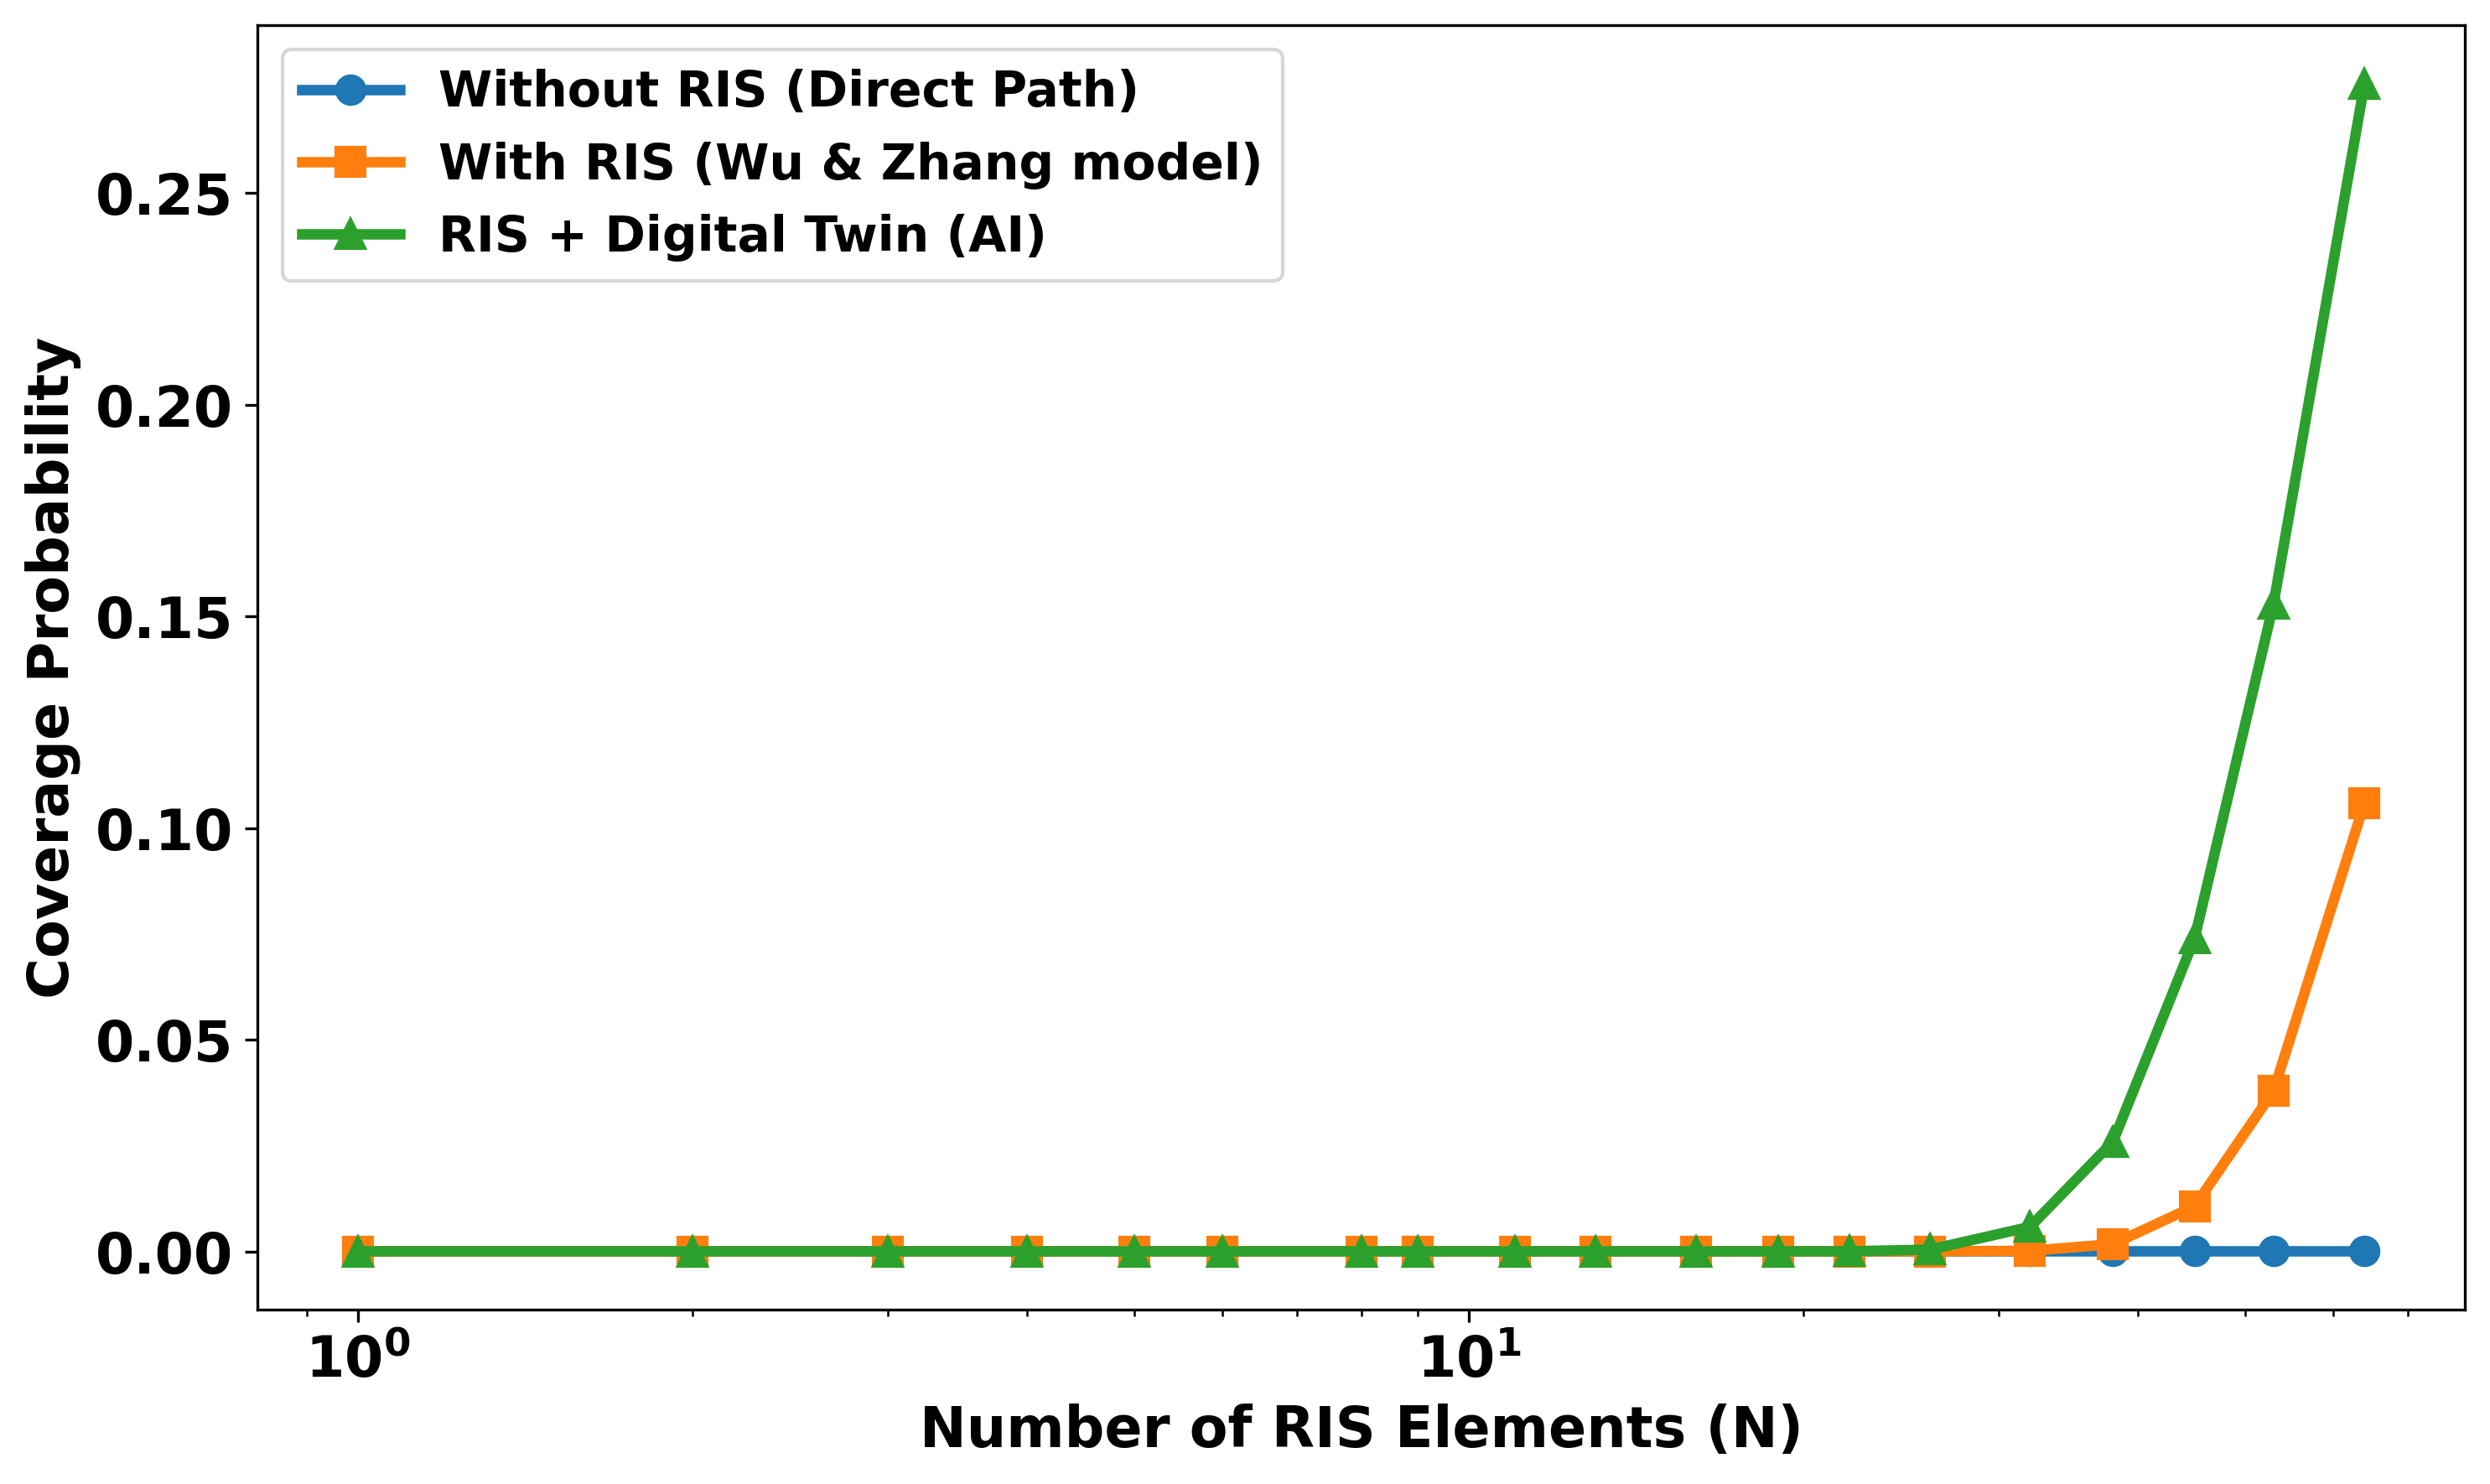

In [26]:
import numpy as np

import math

import matplotlib.pyplot as plt



# ==========================================================

# Number of RIS elements (N) vs Coverage Probability

# ==========================================================



c = 3e8

f_c = 300e9

lam = c / f_c



alpha_db_per_km = 5.2

alpha_db_per_m = alpha_db_per_km / 1000.0



Pt_dbm = 21.9

Pt_w = 10 ** ((Pt_dbm - 30) / 10)



G_rx_db = 20.0

G_rx_lin = 10 ** (G_rx_db / 10)



NF_db = 9.56

k_B = 1.380649e-23

T0 = 290.0

B = 4.32e9

noise_power = k_B * T0 * (10 ** (NF_db / 10)) * B



d_tx = 15.0

d_rx = 15.0



eta_ris = 0.80

eta_ai = 0.88

ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10.0)



def gaseous_loss_linear(d_m):

    return 10 ** (-(alpha_db_per_m * d_m) / 10.0)



def pr_direct(Pt_w, d, G_rx_lin):

    fspl = (4 * math.pi * d / lam) ** 2

    gas = gaseous_loss_linear(d)

    return Pt_w * G_rx_lin / fspl * gas



def pr_ris_wu(Pt_w, d_tx, d_rx, N, lam, eta, G_rx_lin):

    num = Pt_w * G_rx_lin * (N ** 2) * (lam ** 2) * eta

    denom = (4 * math.pi) ** 3 * (d_tx ** 2) * (d_rx ** 2)

    return (num / denom) * gaseous_loss_linear(d_tx + d_rx)



R_th = 3.0

gamma_th = 2 ** R_th - 1



N_values = np.unique(np.logspace(0, 6, num=25, base=2, dtype=int))

N_values = np.clip(N_values, 1, None)

N_values = np.array(sorted(list(set(N_values))))



Pcov_noRIS = []

Pcov_RIS = []

Pcov_RIS_AI = []



pr0 = pr_direct(Pt_w, d_tx + d_rx, G_rx_lin)

snr0 = pr0 / noise_power



for N in N_values:

    Pcov0 = math.exp(-gamma_th / snr0)

    Pcov_noRIS.append(Pcov0)



    pr_ris = pr_ris_wu(Pt_w, d_tx, d_rx, N, lam, eta_ris, G_rx_lin)

    snr_ris = pr_ris / noise_power

    Pcov_ris = math.exp(-gamma_th / snr_ris)

    Pcov_RIS.append(Pcov_ris)



    pr_ai = pr_ris * ai_gain_lin * (eta_ai / eta_ris)

    snr_ai = pr_ai / noise_power

    Pcov_ai = math.exp(-gamma_th / snr_ai)

    Pcov_RIS_AI.append(Pcov_ai)



plt.figure(figsize=(10, 6), dpi=300)



plt.semilogx(N_values, Pcov_noRIS, 'o-', linewidth=3, markersize=8, label='Without RIS (Direct Path)')

plt.semilogx(N_values, Pcov_RIS, 's-', linewidth=3, markersize=8, label='With RIS (Wu & Zhang model)')

plt.semilogx(N_values, Pcov_RIS_AI, '^-', linewidth=3, markersize=8, label='RIS + Digital Twin (AI)')



plt.xlabel('Number of RIS Elements (N)', fontsize=16, fontweight='bold')

plt.ylabel('Coverage Probability', fontsize=16, fontweight='bold')



plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')

plt.legend(prop={'weight': 'bold', 'size': 14})



plt.tight_layout()

plt.show()

<Figure size 3600x1800 with 0 Axes>

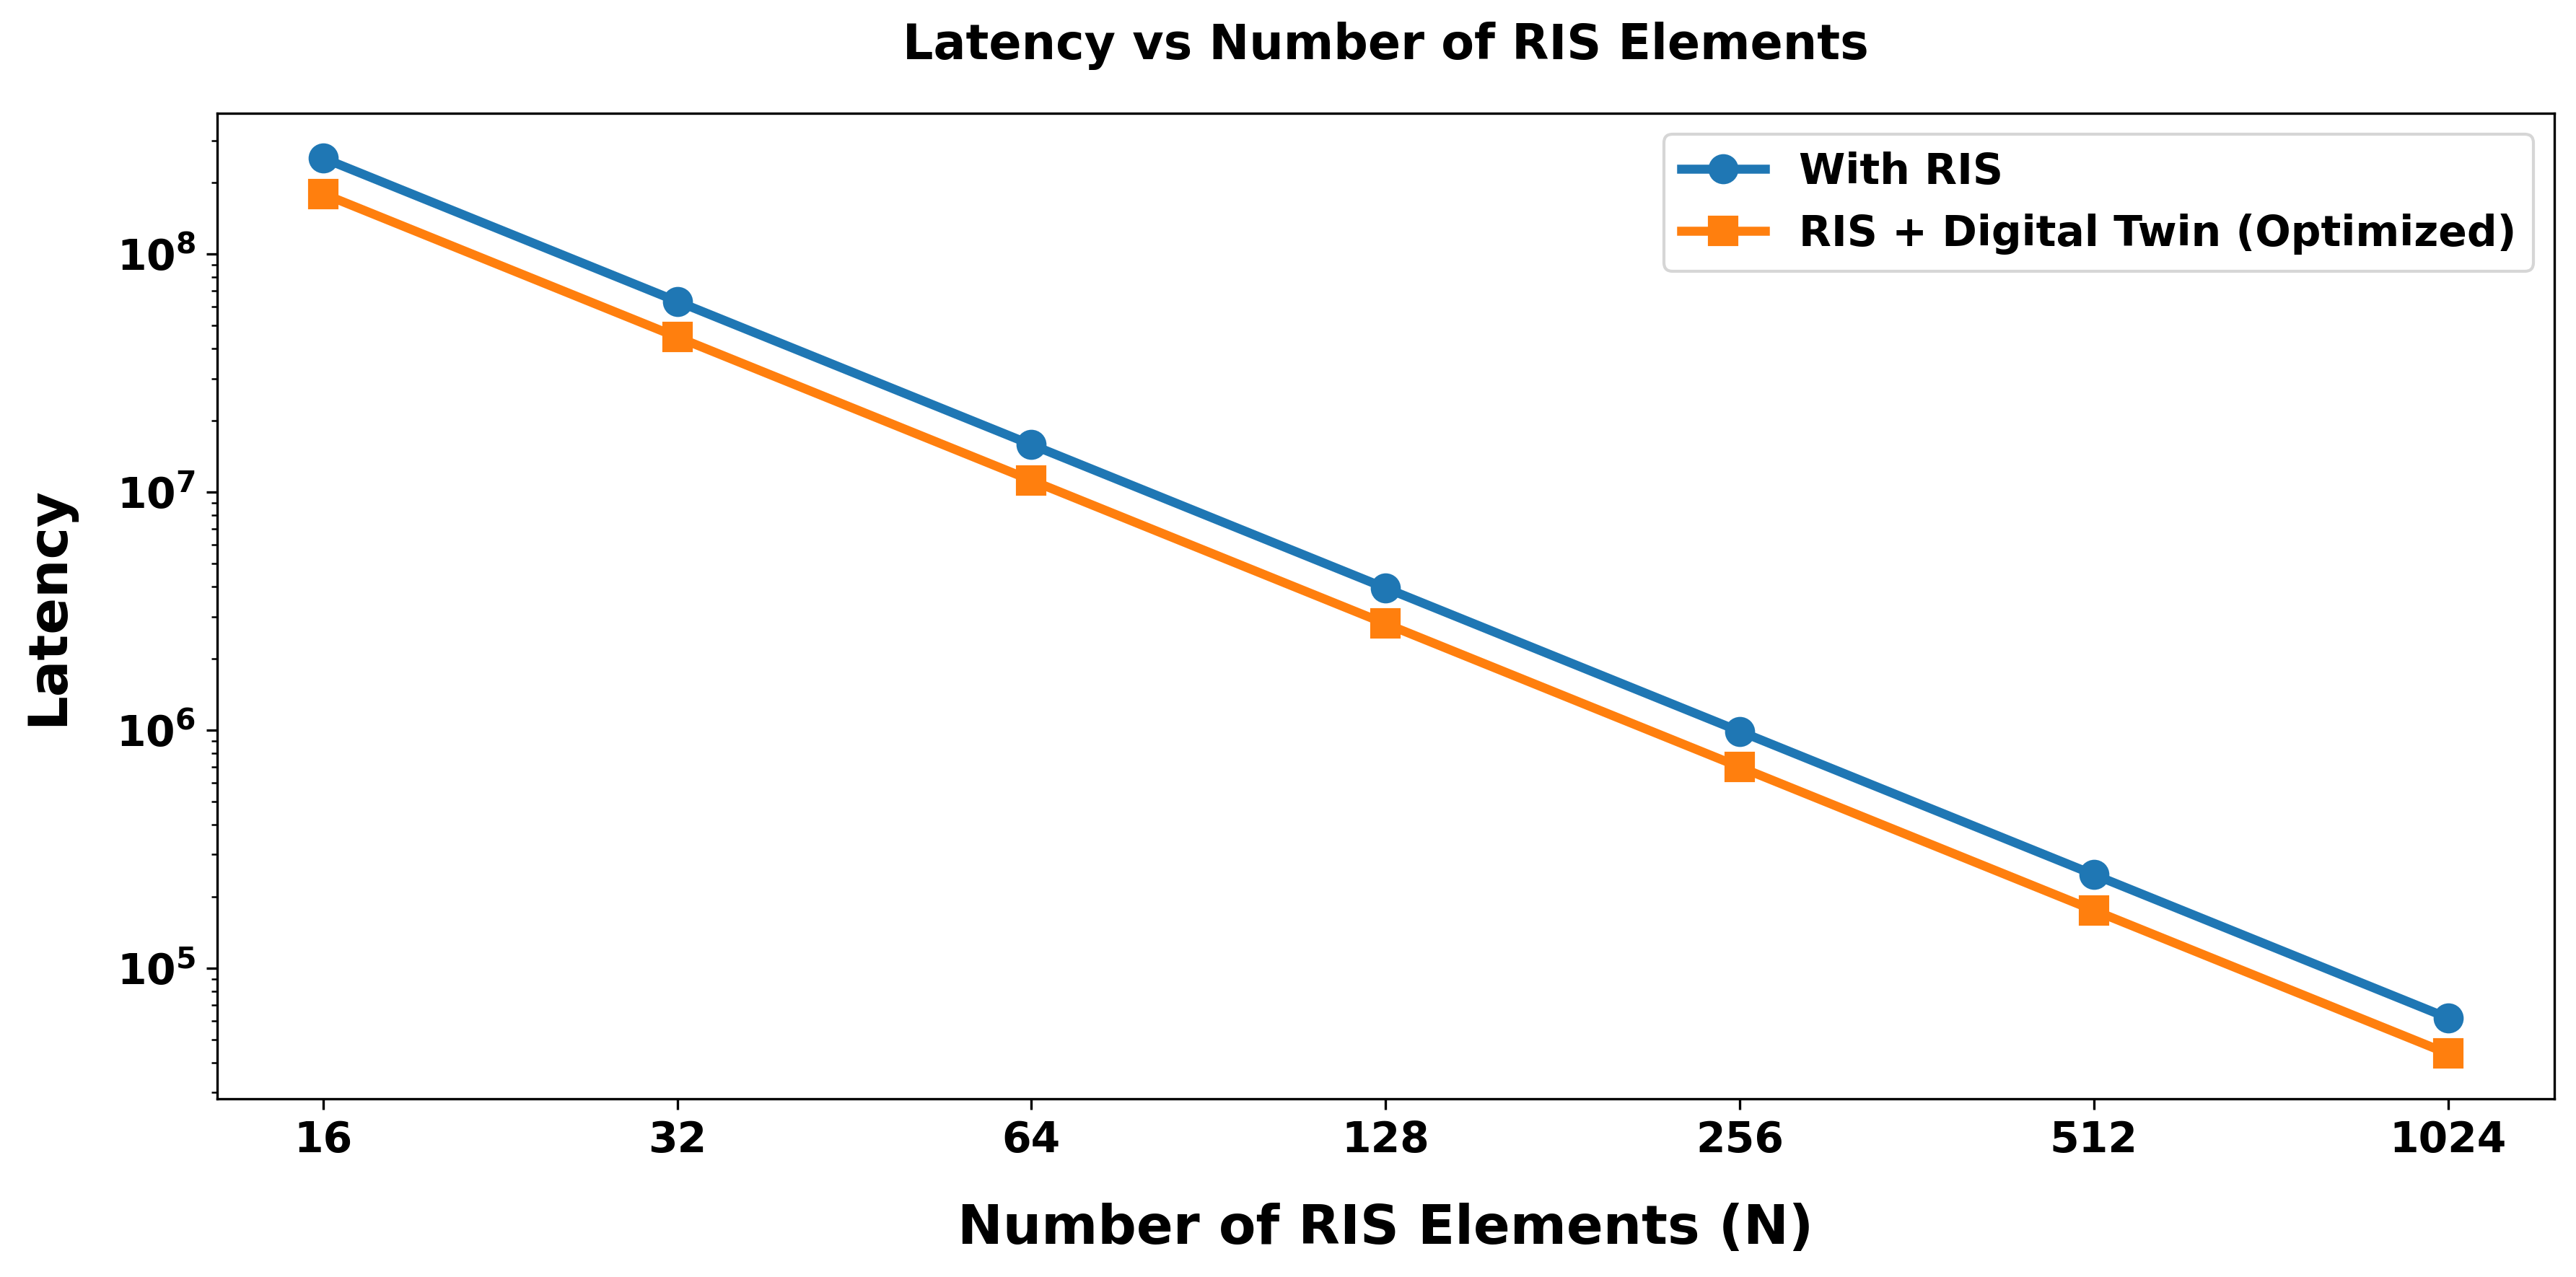

In [33]:
# --------------------------------------

# HD PLOT (FINAL FIXED VERSION)

# --------------------------------------

plt.figure(figsize=(12, 6), dpi=300)



plt.plot(

    N_values,

    lat_ris * 1e3,

    'o-',

    linewidth=3,

    markersize=9,

    label='With RIS'

)



plt.plot(

    N_values,

    lat_ris_dt * 1e3,

    's-',

    linewidth=3,

    markersize=9,

    label='RIS + Digital Twin (Optimized)'

)



plt.xlabel(

    'Number of RIS Elements (N)',

    fontsize=18,

    fontweight='bold',

    labelpad=14

)



plt.ylabel(

    'Latency',

    fontsize=18,

    fontweight='bold',

    labelpad=14

)



# ✅ FINAL FIX FOR OVERLAP

positions = np.arange(len(N_values))



plt.xticks(

    positions,

    ['16', '32', '64', '128', '256', '512', '1024'],

    fontsize=14,

    fontweight='bold'

)



# plot using normal positions instead of actual N values

plt.clf()



plt.figure(figsize=(12, 6), dpi=300)



plt.plot(

    positions,

    lat_ris * 1e3,

    'o-',

    linewidth=3,

    markersize=9,

    label='With RIS'

)



plt.plot(

    positions,

    lat_ris_dt * 1e3,

    's-',

    linewidth=3,

    markersize=9,

    label='RIS + Digital Twin (Optimized)'

)



plt.xticks(

    positions,

    ['16', '32', '64', '128', '256', '512', '1024'],

    fontsize=14,

    fontweight='bold'

)



plt.yticks(fontsize=14, fontweight='bold')



plt.xlabel(

    'Number of RIS Elements (N)',

    fontsize=18,

    fontweight='bold',

    labelpad=14

)



plt.ylabel(

    'Latency',

    fontsize=18,

    fontweight='bold',

    labelpad=14

)



plt.title(

    'Latency vs Number of RIS Elements',

    fontsize=16,

    fontweight='bold',

    pad=18

)



plt.yscale('log')



plt.legend(

    prop={'weight': 'bold', 'size': 14},

    loc='upper right'

)



plt.tight_layout()

plt.show()

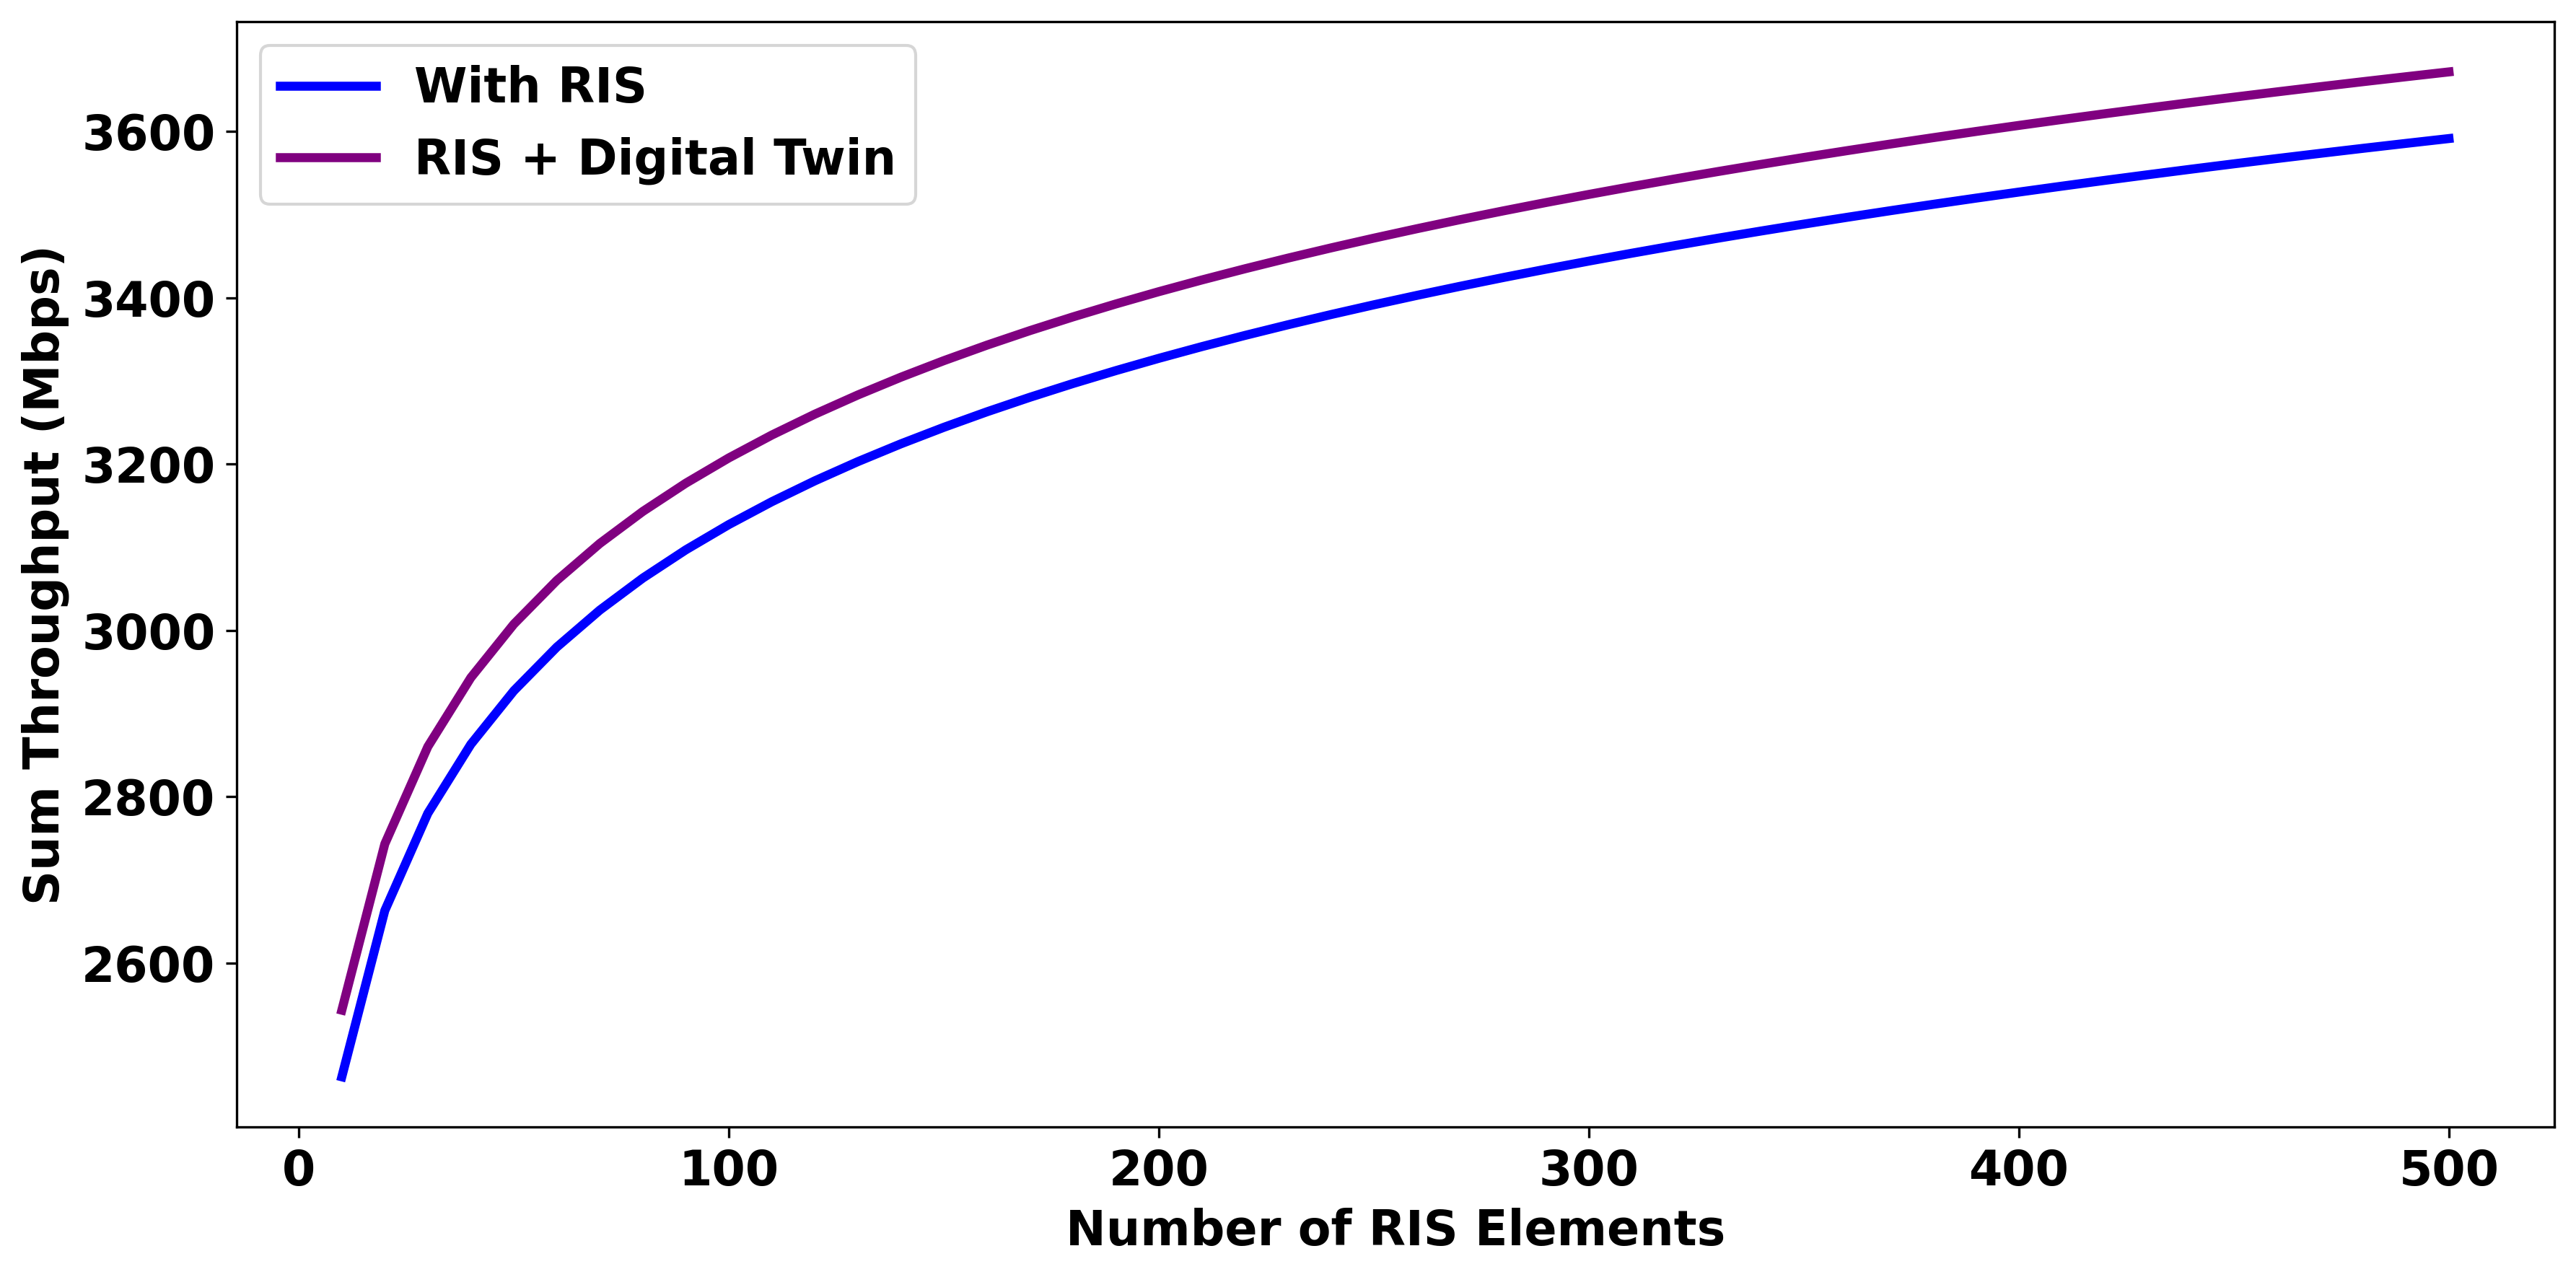

In [36]:
import numpy as np

import math

import matplotlib.pyplot as plt



# --------------------------

# 1) Physics + literature-sourced constants

# --------------------------

c = 3e8

f_c = 3.5e9                        # 3.5 GHz

lam = c / f_c



B = 100e6                          # 100 MHz bandwidth



Pt_dbm = 30

Pt_w = 10 ** ((Pt_dbm - 30.0) / 10.0)



G_rx_db = 10

G_rx_lin = 10 ** (G_rx_db / 10.0)



NF_db = 6

k_B = 1.380649e-23

T0 = 290



N0_w = k_B * T0 * B * (10 ** (NF_db / 10.0))



# Geometry

d_tx_rx = 30.0

d_tx_ris = 15.0

d_ris_rx = 15.0



# RIS parameters

A_ris = 1.0

eta_ris = 0.8

eta_ris_dt = 0.88



# AI / Digital Twin gain

ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10.0)



# --------------------------

# 2) Physics functions

# --------------------------

def fspl_linear(d):

    return (4.0 * math.pi * d / lam) ** 2



def pr_direct(Pt_w, d, G_rx_lin):

    return Pt_w * G_rx_lin / fspl_linear(d)



def pr_ris(Pt_w, d_tx_ris, d_ris_rx, N_ris, eta, G_rx_lin):

    d_total = d_tx_ris + d_ris_rx

    pl = fspl_linear(d_total)

    return Pt_w * G_rx_lin * eta * (N_ris**2) / pl



# --------------------------

# 3) Sweep number of RIS elements

# --------------------------

N_ris_array = np.arange(10, 510, 10)



throughput_no_ris = []

throughput_ris = []

throughput_ris_dt = []



pr0 = pr_direct(Pt_w, d_tx_rx, G_rx_lin)

snr0 = pr0 / N0_w

C0 = B * np.log2(1 + snr0)



throughput_no_ris = [C0 / 1e6] * len(N_ris_array)



for N in N_ris_array:



    pr1 = pr_ris(

        Pt_w,

        d_tx_ris,

        d_ris_rx,

        N,

        eta_ris,

        G_rx_lin

    )



    snr1 = pr1 / N0_w

    C1 = B * np.log2(1 + snr1)



    throughput_ris.append(C1 / 1e6)



    pr2 = pr1 * ai_gain_lin * (eta_ris_dt / eta_ris)



    snr2 = pr2 / N0_w

    C2 = B * np.log2(1 + snr2)



    throughput_ris_dt.append(C2 / 1e6)



# --------------------------

# 4) Plotting - publication style

# --------------------------

plt.figure(figsize=(12,6), dpi=300)



plt.plot(

    N_ris_array,

    throughput_ris,

    label='With RIS',

    linewidth=3,

    color='blue'

)



plt.plot(

    N_ris_array,

    throughput_ris_dt,

    label='RIS + Digital Twin',

    linewidth=3,

    color='purple'

)



plt.xlabel(

    'Number of RIS Elements',

    fontsize=16,

    fontweight='bold'

)



plt.ylabel(

    'Sum Throughput (Mbps)',

    fontsize=16,

    fontweight='bold'

)


plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')



plt.legend(

    prop={'weight': 'bold', 'size': 16}

)



plt.tight_layout()

plt.show()

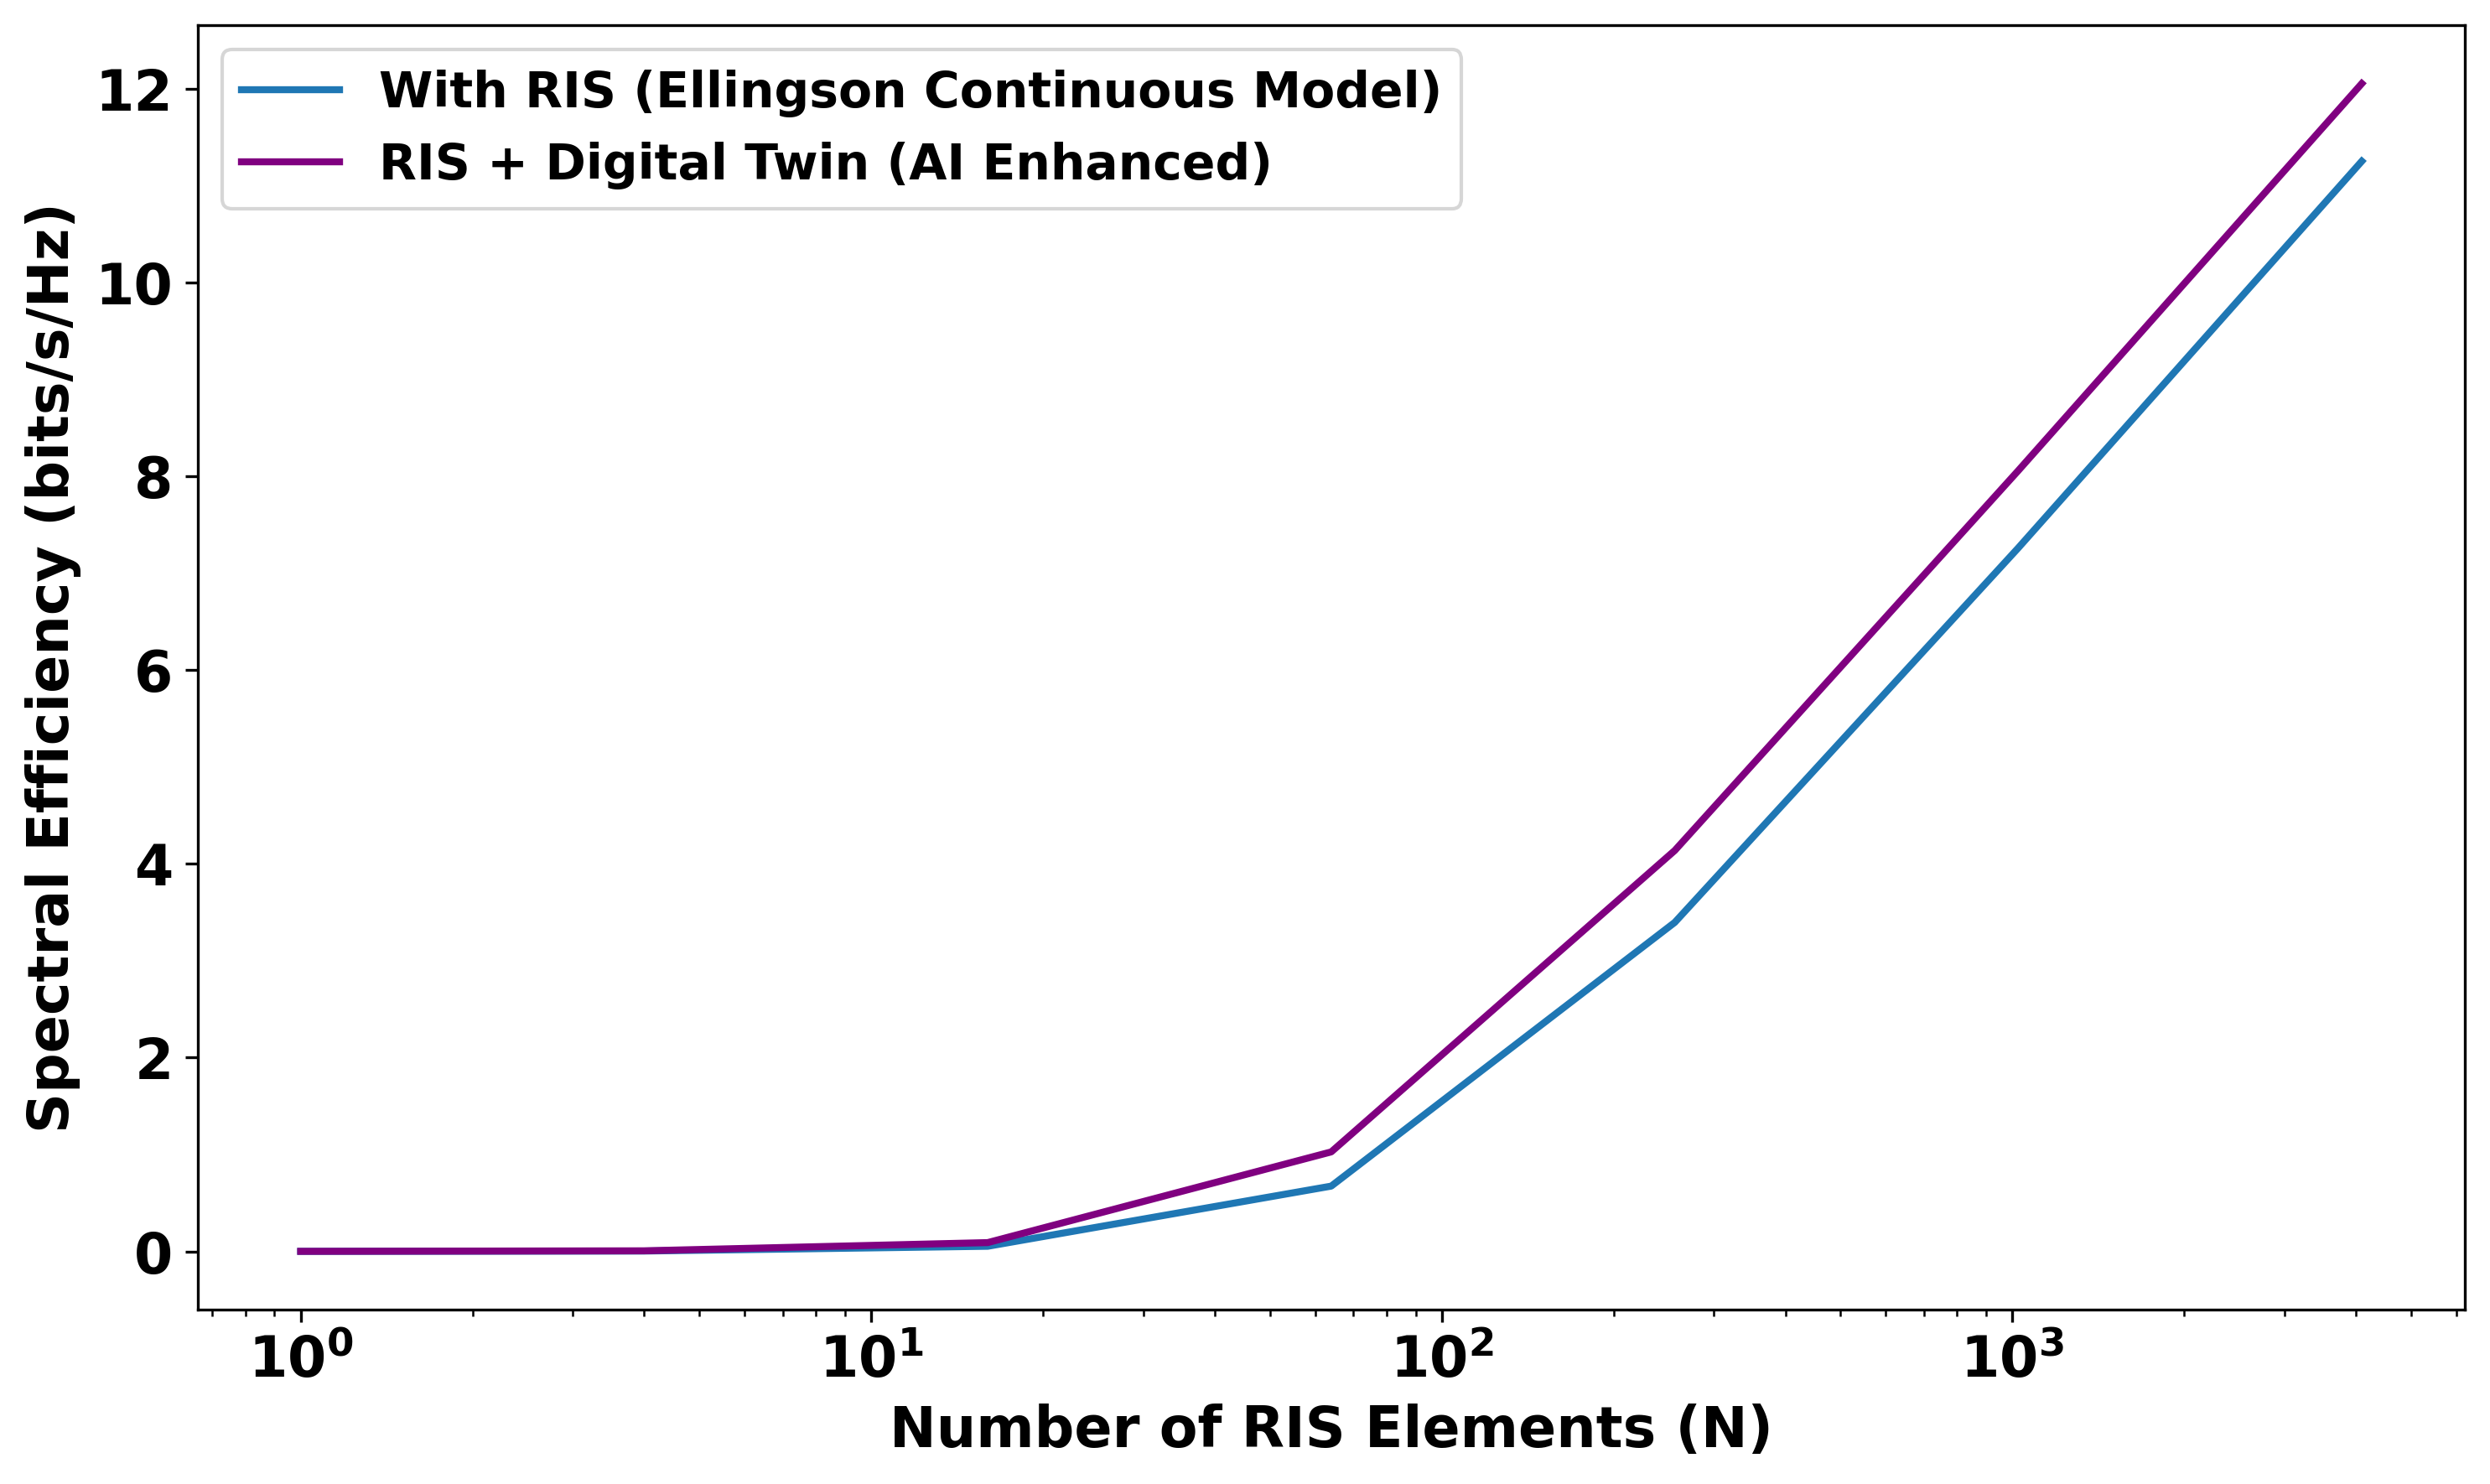

In [38]:
import numpy as np

import math

import matplotlib.pyplot as plt



# ==========================================================

# 1) Constants & literature-based physical parameters

# ==========================================================



c = 3e8

f_c = 300e9

lam = c / f_c



alpha_db_per_km = 5.2

alpha_db_per_m = alpha_db_per_km / 1000.0



Pt_eirp_dbm = 21.9

Pt_w = 10 ** ((Pt_eirp_dbm - 30) / 10)



G_rx_db = 20.0

G_rx_lin = 10 ** (G_rx_db / 10)



NF_db = 9.56

k_B = 1.380649e-23

T0 = 290.0

B = 4.32e9



N0_w = k_B * T0 * (10 ** (NF_db / 10))



d_total = 30.0



eta_ris = 0.80

eta_ai = 0.88

ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10.0)



# ==========================================================

# 2) Core physical models

# ==========================================================



def fspl_linear(d):

    return (4 * math.pi * d / lam) ** 2



def gaseous_loss_linear(d):

    return 10 ** (-(alpha_db_per_m * d) / 10.0)



def pr_direct(Pt_w, d, G_rx_lin):

    pl = fspl_linear(d)

    gas = gaseous_loss_linear(d)

    return Pt_w * G_rx_lin / pl * gas



def pr_ris_continuous(Pt_w, d_tx, d_rx, A_ris, eta, G_rx_lin):

    d_sum = d_tx + d_rx

    pl_ris = (4 * math.pi * d_sum / lam) ** 2 / ((A_ris ** 2) * eta)

    gas = gaseous_loss_linear(d_sum)

    return Pt_w * G_rx_lin / pl_ris * gas



# ==========================================================

# 3) Sweep number of RIS elements

# ==========================================================



N_values = np.array([1, 4, 16, 64, 256, 1024, 4096])



SE_noRIS = []

SE_RIS = []

SE_RIS_AI = []



A_elem = (lam / 2) ** 2



d_tx = d_total / 2.0

d_rx = d_total / 2.0



for N in N_values:



    A_ris = N * A_elem



    pr0 = pr_direct(Pt_w, d_total, G_rx_lin)

    snr0 = pr0 / N0_w

    SE0 = np.log2(1 + snr0)

    SE_noRIS.append(SE0)



    pr_ris = pr_ris_continuous(

        Pt_w,

        d_tx,

        d_rx,

        A_ris,

        eta_ris,

        G_rx_lin

    )



    snr_ris = pr_ris / N0_w

    SE_ris = np.log2(1 + snr_ris)

    SE_RIS.append(SE_ris)



    pr_ai = pr_ris * ai_gain_lin * (eta_ai / eta_ris)

    snr_ai = pr_ai / N0_w

    SE_ai = np.log2(1 + snr_ai)

    SE_RIS_AI.append(SE_ai)



# ==========================================================

# 4) Plot: Number of RIS Elements vs Spectral Efficiency

# ==========================================================



plt.figure(figsize=(10,6), dpi=300)



plt.semilogx(

    N_values,

    SE_RIS,

    label='With RIS (Ellingson Continuous Model)',

    linewidth=2

)



plt.semilogx(

    N_values,

    SE_RIS_AI,

    label='RIS + Digital Twin (AI Enhanced)',

    linewidth=2,

    color='purple'

)



plt.xlabel(

    'Number of RIS Elements (N)',

    fontsize=16,

    fontweight='bold'

)



plt.ylabel(

    'Spectral Efficiency (bits/s/Hz)',

    fontsize=16,

    fontweight='bold'

)


plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')


plt.legend(

    prop={'weight': 'bold', 'size': 14},

    loc='best'

)



plt.tight_layout()

plt.show()

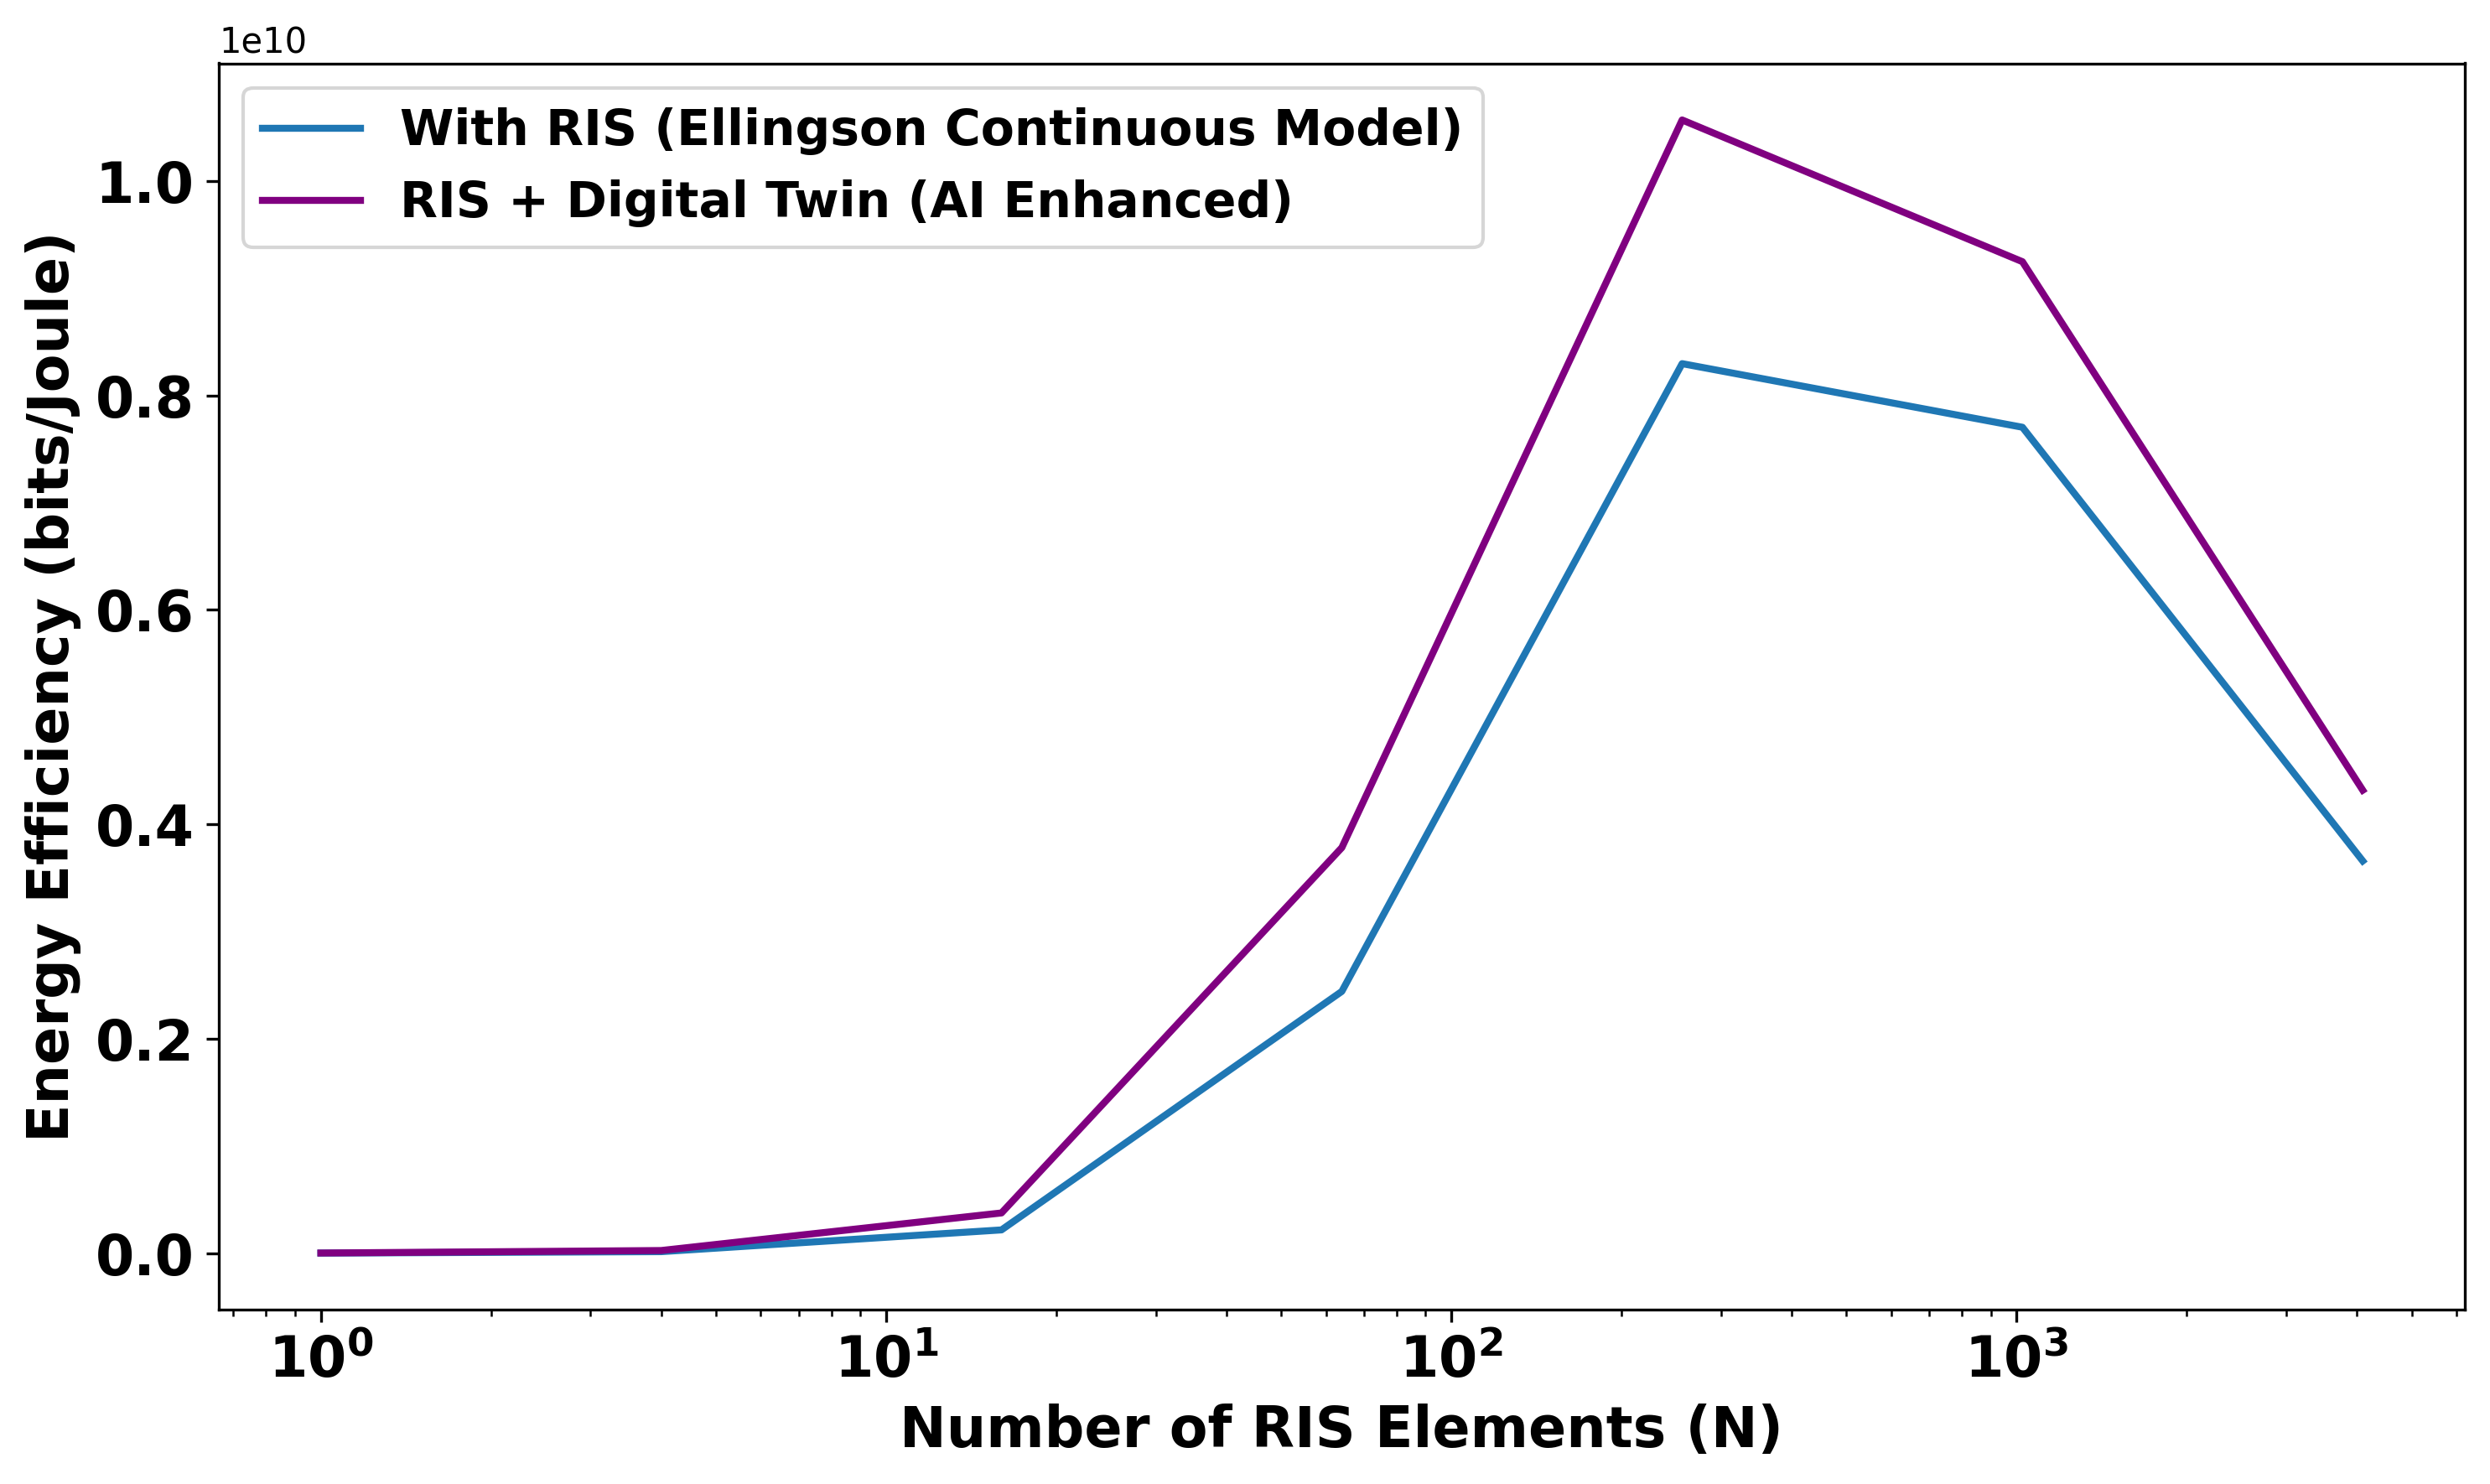

In [40]:
import numpy as np

import math

import matplotlib.pyplot as plt



# ==========================================================

# 1) Constants & literature-based physical parameters

# ==========================================================



c = 3e8

f_c = 300e9

lam = c / f_c



alpha_db_per_km = 5.2

alpha_db_per_m = alpha_db_per_km / 1000.0



Pt_eirp_dbm = 21.9

Pt_w = 10 ** ((Pt_eirp_dbm - 30) / 10)



G_rx_db = 20.0

G_rx_lin = 10 ** (G_rx_db / 10)

NF_db = 9.56



k_B = 1.380649e-23

T0 = 290.0

B = 4.32e9

N0_w = k_B * T0 * (10 ** (NF_db / 10))



d_total = 30.0

d_tx = d_total / 2.0

d_rx = d_total / 2.0



eta_ris = 0.80

eta_ai = 0.88

ai_gain_db = 2.0

ai_gain_lin = 10 ** (ai_gain_db / 10.0)



P_circuit = 1.0

P_elem = 3e-3

P_ai_factor = 0.9



# ==========================================================

# 2) Core physical models

# ==========================================================



def fspl_linear(d):

    return (4 * math.pi * d / lam) ** 2



def gaseous_loss_linear(d):

    return 10 ** (-(alpha_db_per_m * d) / 10.0)



def pr_direct(Pt_w, d, G_rx_lin):

    pl = fspl_linear(d)

    gas = gaseous_loss_linear(d)

    return Pt_w * G_rx_lin / pl * gas



def pr_ris_continuous(Pt_w, d_tx, d_rx, A_ris, eta, G_rx_lin):

    d_sum = d_tx + d_rx

    pl_ris = (4 * math.pi * d_sum / lam) ** 2 / ((A_ris ** 2) * eta)

    gas = gaseous_loss_linear(d_sum)

    return Pt_w * G_rx_lin / pl_ris * gas



# ==========================================================

# 3) Sweep number of RIS elements

# ==========================================================



N_values = np.array([1, 4, 16, 64, 256, 1024, 4096])



EE_noRIS = []

EE_RIS = []

EE_RIS_AI = []



A_elem = (lam / 2) ** 2



for N in N_values:

    A_ris = N * A_elem



    pr0 = pr_direct(Pt_w, d_total, G_rx_lin)

    snr0 = pr0 / N0_w

    SE0 = np.log2(1 + snr0)

    P_total_0 = P_circuit

    EE0 = (B * SE0) / P_total_0

    EE_noRIS.append(EE0)



    pr_ris = pr_ris_continuous(

        Pt_w,

        d_tx,

        d_rx,

        A_ris,

        eta_ris,

        G_rx_lin

    )



    snr_ris = pr_ris / N0_w

    SE_ris = np.log2(1 + snr_ris)

    P_total_ris = P_circuit + (N * P_elem)

    EE_ris = (B * SE_ris) / P_total_ris

    EE_RIS.append(EE_ris)



    pr_ai = pr_ris * ai_gain_lin * (eta_ai / eta_ris)

    snr_ai = pr_ai / N0_w

    SE_ai = np.log2(1 + snr_ai)

    P_total_ai = P_circuit + (N * P_elem * P_ai_factor)

    EE_ai = (B * SE_ai) / P_total_ai

    EE_RIS_AI.append(EE_ai)



# ==========================================================

# 4) Plot: Number of RIS Elements vs Energy Efficiency

# ==========================================================



plt.figure(figsize=(10, 6), dpi=300)



plt.semilogx(

    N_values,

    EE_RIS,

    label='With RIS (Ellingson Continuous Model)',

    linewidth=2

)



plt.semilogx(

    N_values,

    EE_RIS_AI,

    label='RIS + Digital Twin (AI Enhanced)',

    linewidth=2,

    color='purple'

)



plt.xlabel(

    'Number of RIS Elements (N)',

    fontsize=16,

    fontweight='bold'

)



plt.ylabel(

    'Energy Efficiency (bits/Joule)',

    fontsize=16,

    fontweight='bold'

)




plt.xticks(fontsize=16, fontweight='bold')

plt.yticks(fontsize=16, fontweight='bold')


plt.legend(

    prop={'weight': 'bold', 'size': 14},

    loc='best'

)



plt.tight_layout()

plt.show()